# COGS 108 - Final Project: Risk Factors and Model Fairness in Machine Learning for Undiagnosed Diabetes: An Analysis of NHANES 2017-2018

## Permissions

Place an X in the appropriate bracket below to specify if you would like your group's project to be
made available to the public, including the names of the authors.

- YES - make available ☐  
- NO  - keep private ☒

## Link to video

https://www.youtube.com/watch?v=Llj_J_lhgQ0

## Abstract
### Background:
The CDC estimates that a quarter of U.S. adults with diabetes remain undiagnosed, increasing the risk of severe complications later on. Prior literature using the National Health and Nutrition Examination Survey (NHANES) identified disparities in diabetes incidence and diagnosis across racial/ethnic and socioeconomic groups. However, it is not clear which non-clinical factors drive *awareness* of diabetes among those who meet biomarker criteria for it.

### Objectives:
This study investigates (1) which non-clinical variables – namely, sex, race, ethnicity, education, income, health insurance, source of care, time since previous routine health check-up, exercise, smoking, and alcohol usage – are associated with remaining undiagnosed?; (2) how well can we predict whether a person is aware of their diabetes using only these non‑clinical variables, and which non-clinical variables drive this awareness?; and (3) model fairness, i.e. whether predictive performance differs across race/ethnicity and income groups.

### Methods:
We analyzed adults (≥18 years) from NHANES 2017–2018 who met diabetes criteria based on hemoglobin A1c or fasting plasma glucose. Participants' awareness of their diabetes was self-reported. Survey-weighted logistic regression was applied to quantify associations of non-clinical variables with undiagnosed diabetes. Predictive models—including logistic regression and random forest—were trained using these non-clinical variables and evaluated using held-out test data. Fairness was assessed by comparing subgroup performance across race/ethnicity and income groups.

### Results:
Multiple non-clinical factors were significantly associated with undiagnosed diabetes. Older age was associated with lower odds of underdiagnosis, while current smoking and certain racial/ethnic minority groups (including non-Hispanic Black and non-Hispanic Asian adults) had higher odds. Socioeconomic and access-related variables showed complex, non-monotonic relationships. Despite these associations, predictive models achieved only modest performance (test AUC ≈ 0.45–0.56), indicating limited ability to classify diagnosis status using non-clinical variables alone. Subgroup analyses suggested variation in model performance across race/ethnicity and income, though estimates were not significant, likely due to small sample sizes.

### Conclusions:
Non-clinical factors are associated with diabetes awareness and reflect broader inequities in access to care, but they are insufficient for accurate prediction of an individual's undiagnosed status. These findings highlight the distinction between statistical association and predictive utility and underscore the need for richer data and equity-focused evaluation when developing screening models for diabetes.


### Note on AI Usage, as the syllabus asks for

Some code in this project was written with the help of ChatGPT. We used it mostly for help with implementation details (e.g., syntax, debugging, and structuring functions). All research questions, modeling decisions, data processing, and interpretation of results were designed and carried out by our team. We reviewed, edited, and validated all AI-generated code to ensure it was correct and aligned with the aims of our analysis.

ChatGPT was also used to help improve us word our comments and explanations better. All ideas, interpretations, and conclusions are completely from our team, and we edited any AI-generated text to ensure it accurately reflects our intellectual work.

## Authors

Pranava Gande - Conceptualization, Project administration, Writing - original draft
Jenna Cheng - Background research, analysis
Alexa Covarrubias - Data curation, Writing - review and editing
Monique Ramirez - Visualization, Software
Sinai Brito - Experimental investigation, Methodology

## Research Question

This project is about U.S. adults from the 2017-2018 National Health and Nutrition Examination Survey (NHANES) who meet the biomarker criteria for diabetes (either from tests of hemoglobin A1c or fasting plasma glucose). We ask three related questions:

1. **Association:** Which non-clinical variables – namely, sex, race, ethnicity, education, income, health insurance, source of care, time since previous routine health check-up, exercise, smoking, and alcohol usage – are associated with remaining *undiagnosed*?

2. **Prediction:** How well can we predict whether a person is aware of their diabetes (i.e. diagnosed vs. undiagnosed) using only these non‑clinical variables, and which variables have the highest feature importance in our models?

3. **Fairness:** Does classification performance differ across race/ethnicity or income, thereby challenging the equity of non‑laboratory screening models?

These questions were motivated by the high prevalence of undiagnosed diabetes, as well as increasing concerns about the fairness of machine learning models.

## Background and Prior Work

Diabetes is among the most common chronic conditions in the United States, and it is a leading driver of illness, disability, and healthcare spending.[[1]](#ref1)[[2]](#ref2) According to CDC estimates, tens of millions of U.S. adults have diabetes, with roughly a quarter being unaware [[1]](#ref1). High blood sugar can remain asymptomatic while causing insidious health effects, damaging many organ systems.[[3]](#ref3) Thus, people who remain undiagnosed, due to not adhering to routine health checkups for example, may first present with complications, including cardiovascular disease, kidney disease, or ocular damage.[[3]](#ref3)[[4]](#ref4) This makes early detection of diabetes critical.[[4]](#ref4)

NHANES is a nationally representative cross-sectional survey that provides interviews, physical exam results, and laboratory test data from the U.S. population.[[5]](#ref5) It is among the main data sources used to monitor the incidence and burden of diabetes, both diagnosed and undiagnosed, at population-scale.[[1]](#ref1)[[5]](#ref5)[[6]](#ref6) For each participant, it documents whether a physician has diagnosed diabetes as well as lab biomarker (hemoglobin A1c and fasting plasma glucose) results.[[5]](#ref5)[[6]](#ref6) This wealth of data has resulted in many important recent epidemiological findings.[[1]](#ref1)[[6]](#ref6) This includes documenting healthcare inequities; namely, Black, Hispanic, and Asian adults have a higher prevalence of both diagnosed and undiagnosed diabetes than non-Hispanic White adults.[[6]](#ref6) In addition, participants with lower education levels were also found to have higher rates of undiagnosed diabetes.[[6]](#ref6) These findings indicate that there are broader inequities in which people are likely to be made aware of their diabetes via formal diagnosis.[[3]](#ref3)[[6]](#ref6)[[7]](#ref7)

There have been a few studies that have linked other non-clinical variables to diabetes diagnosis. These include variables that are not related to healthcare equity. For example, Wilder et al. showed that obesity was linked to undiagnosed diabetes in NHANES III (1988-1994).[[8]](#ref8) In the Korean NHANES (KNHANES 2008-2011), a replica of the NHANES dataset at a national scale in Korea, it was found that cardiometabolic risk factors like hypertension and dyslipidemia were also linked to undiagnosed diabetes.[[9]](#ref9) Thus, undiagnosed diabetes is affected by the interplay of numerous different social and medical factors, which can be difficult to disentangle despite the high stakes.[[3]](#ref3)[[4]](#ref4)[[8]](#ref8)[[9]](#ref9) This makes the problem an ideal candidate for data science approaches.

There is a growing line of work that aims to do exactly this, i.e. detect undiagnosed diabetes solely from easily measured variables.[[10]](#ref10)[[11]](#ref11) A recent study in JMIR AI trained a model on NHANES 1999-2000 that used demographics, anthropometric measures, health behaviors and some other clinical variables.[[10]](#ref10) This model achieved an AUC of 0.91 in the task of classifying adults with undiagnosed diabetes and healthy adults.[[10]](#ref10) For comparison, an AUC above 0.8 is generally considered clinically usable for medical diagnostic models.[[13]](#ref13) Another paper by Riveros Perez and Avella-Molano reported that XGBoost achieved an AUC of 0.82 on the same task using only lifestyle and anthropometric measurements in NHANES 2007-2008.[[11]](#ref11) These studies are promising results that suggest that data science models might support early risk screening for diabetes.[[10]](#ref10)[[11]](#ref11)

Our project is also a predictive-modelling task, but otherwise differs from previous studies in the field.[[10]](#ref10)[[11]](#ref11) We focus on a different population – adults in NHANES 2017-2018 who already meet biomarker criteria for diabetes.[[5]](#ref5)[[6]](#ref6)[[12]](#ref12) In this group, we aim to model awareness of diabetes status and discover the features that most explain this awareness gap.[[4]](#ref4)[[7]](#ref7) As such, our work builds on previous NHANES studies of undiagnosed diabetes.[[4]](#ref4)[[8]](#ref8)[[9]](#ref9)[[10]](#ref10)[[11]](#ref11) Prior results are taken a step further by applying a novel predictive model to discover who among those with diabetes remain undiagnosed.[[10]](#ref10)[[11]](#ref11) These results will also shed light on equity-related questions to understand how diabetes screening models may contend with different demographic groups.[[3]](#ref3)[[6]](#ref6)[[7]](#ref7)

<a id="ref1"></a>[1] Centers for Disease Control and Prevention. *National Diabetes Statistics Report.* Atlanta, GA: U.S. Department of Health and Human Services. Available at: https://www.cdc.gov/diabetes/php/data-research/

<a id="ref2"></a>[2] American Diabetes Association. *Economic Costs of Diabetes in the U.S. in 2017.* Diabetes Care. 2018;41(5):917–928. PubMed: https://pubmed.ncbi.nlm.nih.gov/29567642/

<a id="ref3"></a>[3] Mayo Clinic. *Hyperglycemia in diabetes – Symptoms and causes.* Available at: https://www.mayoclinic.org/diseases-conditions/hyperglycemia/symptoms-causes/syc-20373631

<a id="ref4"></a>[4] Centers for Disease Control and Prevention. *How Diabetes Can Affect Your Body.* Infographic. Available at: https://www.cdc.gov/diabetes/communication-resources/how-diabetes-can-affect-your-body.html

<a id="ref5"></a>[5] National Center for Health Statistics. *National Health and Nutrition Examination Survey (NHANES) – Overview and Methods.* Available at: https://www.cdc.gov/nchs/hus/sources-definitions/nhanes.htm

<a id="ref6"></a>[6] Centers for Disease Control and Prevention. *Appendix A: Detailed Tables for the National Diabetes Statistics Report (2017–2020).* Table 1: Age-adjusted prevalence of diagnosed, undiagnosed, and total diabetes among adults, by race/ethnicity and education. Available at: https://www.cdc.gov/diabetes/php/data-research/appendix.html

<a id="ref7"></a>[7] To KG et al. *Awareness of having hypertension, diabetes and dyslipidaemia among US adults: The 2011–2018 NHANES data.* Scand J Public Health. 2025;53(4):391–399. PubMed: https://pubmed.ncbi.nlm.nih.gov/38679806/

<a id="ref8"></a>[8] Wilder RP, Majumdar SR, Klarenbach SW, Jacobs P. *Socio-economic status and undiagnosed diabetes.* Diabetes Res Clin Pract. 2005;70(1):26–30. PubMed: https://pubmed.ncbi.nlm.nih.gov/16126120/

<a id="ref9"></a>[9] Kim JH et al. *Prevalence and Risk Factors for Undiagnosed Glucose Intolerance Status in Apparently Healthy Young Adults Aged <40 Years: The Korean National Health and Nutrition Examination Survey 2014–2017.* Int J Environ Res Public Health. 2019;16(13):2396. PMC: https://www.ncbi.nlm.nih.gov/pmc/articles/PMC6651181/

<a id="ref10"></a>[10] Liu J et al. *Use of Automated Machine Learning to Detect Undiagnosed Diabetes in US Adults: Development and Validation Study.* JMIR AI. 2025;4:e68260. Available at: https://ai.jmir.org/2025/1/e68260

<a id="ref11"></a>[11] Riveros Perez E, Avella-Molano B. *Learning from the machine: is diabetes in adults predicted by lifestyle variables? A retrospective predictive modelling study of NHANES 2007–2018.* BMJ Open. 2025;15(3):e096595. Available at: https://bmjopen.bmj.com/content/15/3/e096595

<a id="ref12"></a>[12] National Center for Health Statistics. *NHANES 2017–2018 Glycohemoglobin (GHB_J) Data Documentation, Codebook, and Frequencies.* Available at: https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/GHB_J.htm

<a id="ref13"></a>[13] Fan J, Upadhye S, Worster A. *Understanding receiver operating characteristic (ROC) curves.* CJEM. 2006;8(1):19–20. (See also: *Assessing the Accuracy of Diagnostic Tests* – Table 2 AUC interpretation.) PMC: https://www.ncbi.nlm.nih.gov/pmc/articles/PMC6410404/

## Hypothesis


We have four hypotheses, grounded in the literature outlined in the background.

- **H1 (Healthcare access and underdiagnosis).**
Among U.S. adults meeting the biomarker criteria for diabetes in NHANES 2017-2018, being undiagnosed will be **more common** in those with worse healthcare access. Specific indicators of this include lower income, lack of health insurance, no consistent source of care, and longer time since last routine checkup.

- **H2 (Race/ethnicity).** People of color (e.g., Black, Hispanic, Asian adults) will have **higher underdiagnosis** than non‑Hispanic White adults. This disparity persists after controlling for socioeconomic status and healthcare access, reflecting structural inequalities.

- **H3 (Predictive performance).** Predictive models using only non‑clinical variables (demographics, socioeconomic status, access, lifestyle) will achieve **moderate** discrimination, with AUC around **0.7**, when predicting awareness of diabetes status among biomarker‑positive adults. This is slightly worse than the AUCs of models predicting diabetes vs. non-diabetes in undiagnosed patients from NHANES data, reflecting the fact that ours is a slightly harder classification task.

- **H4 (Fairness).** Classification performance (AUC, sensitivity) will **differ** between race/ethnicity and income groups. We expect lower performance in disadvantaged groups, reflecting growing concerns about the (in)equity of machine learning models across many applications.

## Data

We use data from the **2017–2018 National Health and Nutrition Examination Survey (NHANES)**, conducted by the U.S. National Center for Health Statistics (NCHS).

- **Dataset name:** NHANES 2017–2018  
- **URL:** `https://wwwn.cdc.gov/nchs/nhanes/continuousnhanes/default.aspx?BeginYear=2017`  
- **Population:** Non‑institutionalized U.S. residents, sampled via a complex, multistage probability design.  
- **Original size:** 8,704 participants with interview and exam data (approximate; exact number depends on component).  
- **Analytic Dataset:** Adults (≥18 years) who meet **biomarker criteria** for diabetes (based on hemoglobin A1c and fasting plasma glucose), and have non‑missing non‑clinical predictors.

We rely on multiple NHANES component files for this project:

- **Demographics (DEMO_J):** age, sex, race/ethnicity, education, income‑to‑poverty ratio, survey weights.
- **Glycohemoglobin (GHB_J):** hemoglobin A1c (HbA1c).
- **Fasting Plasma Glucose (GLU_J):** fasting plasma glucose.
- **Health Insurance (HIQ_J):** insurance coverage status.
- **Smoking (SMQ_J):** smoking history and current smoking.
- **Alcohol (ALQ_J):** alcohol use.
- **Physical Activity (PAQ_J):** recreational physical activity.
- **Diabetes Questionnaire (DIQ_J):** self‑reported diabetes diagnosis and treatment.

These data are all publicly available, de‑identified, and extensively documented by NCHS.

**Shortcomings for our needs:**

- NHANES is **cross‑sectional**, so we cannot establish causality (e.g., whether gaining insurance would cause diagnosis).
- Some key variables—diagnosis, smoking, alcohol, access—are **self‑reported**, subject to recall bias and social desirability bias.
- NHANES **excludes the unhoused and institutionalized populations**, which may lead us to underestimate the prevalence and underdiagnosis in the most vulnerable groups.
- Some subgroups (e.g., certain race/ethnicity and income combinations) have limited sample sizes, reducing statistical power, especially in fairness analyses.

Despite these limitations, NHANES is well‑suited to our research questions because it provides nationally representative data with detailed biomarker, demographic, and access‑to‑care information.


### Dataset #1: NHANES 2017–2018 

Our pipeline begins with preprocessing. We download and merge each individual NHANES component file, into a csv file `data/01-interim/nhanes_diabetes.csv`. We also create two new columns - (1) `diagnosed` according to the person's self-report and (2) `diabetes_biomarker` according to whether the person meets biomarker criteria of diabetes.

We do this preprocessing using the helper functions `modules/get_data.py` and  `modules/clean_data.py`. Then, we load the processed csv file and do additional feature engineering, tidying, and checks.

In [47]:
# DOWNLOAD AND CLEAN DATA

import sys
sys.path.append('./modules') # this tells python where to look for modules to import

import get_data # this is where we get the function we need to download data
import clean_data

get_data.run_file()
clean_data.clean()

Overall Download Progress:  12%|███████▏                                                 | 1/8 [00:01<00:09,  1.30s/it]

Successfully downloaded: DEMO_J.XPT



Overall Download Progress:  25%|██████████████▎                                          | 2/8 [00:02<00:06,  1.14s/it]

Successfully downloaded: GHB_J.XPT



Overall Download Progress:  38%|█████████████████████▍                                   | 3/8 [00:03<00:05,  1.09s/it]

Successfully downloaded: GLU_J.XPT



Overall Download Progress:  50%|████████████████████████████▌                            | 4/8 [00:04<00:04,  1.10s/it]

Successfully downloaded: HIQ_J.XPT



Overall Download Progress:  62%|███████████████████████████████████▋                     | 5/8 [00:05<00:03,  1.10s/it]

Successfully downloaded: SMQ_J.XPT



Overall Download Progress:  75%|██████████████████████████████████████████▊              | 6/8 [00:06<00:02,  1.06s/it]

Successfully downloaded: ALQ_J.XPT



Overall Download Progress:  88%|█████████████████████████████████████████████████▉       | 7/8 [00:07<00:01,  1.11s/it]

Successfully downloaded: PAQ_J.XPT



Overall Download Progress: 100%|█████████████████████████████████████████████████████████| 8/8 [00:09<00:00,  1.16s/it]


Successfully downloaded: DIQ_J.XPT
Dataset saved to data/01-interim/nhanes_diabetes.csv
Rows: 860
Columns: 181


In [48]:
# LOAD LIBRARIES AND DATA, SET UP PLOTS
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid", context="talk")

import statsmodels.api as sm

from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve
from sklearn.metrics import (
    roc_auc_score, roc_curve, confusion_matrix,
    precision_score, recall_score, brier_score_loss
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import calibration_curve

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

# Load cleaned analytic dataset
df = pd.read_csv("data/01-interim/nhanes_diabetes.csv")
print("Raw merged dataset shape:", df.shape)
df.head()

Raw merged dataset shape: (860, 181)


,SEQN,SDDSRVYR,RIDSTATR,RIAGENDR,RIDAGEYR,RIDAGEMN,RIDRETH1,RIDRETH3,RIDEXMON,RIDEXAGM,DMQMILIZ,DMQADFC,DMDBORN4,DMDCITZN,DMDYRSUS,DMDEDUC3,DMDEDUC2,DMDMARTL,RIDEXPRG,SIALANG,SIAPROXY,SIAINTRP,FIALANG,FIAPROXY,FIAINTRP,MIALANG,MIAPROXY,MIAINTRP,AIALANGA,DMDHHSIZ,DMDFMSIZ,DMDHHSZA,DMDHHSZB,DMDHHSZE,DMDHRGND,DMDHRAGZ,DMDHREDZ,DMDHRMAZ,DMDHSEDZ,WTINT2YR,WTMEC2YR,SDMVPSU,SDMVSTRA,INDHHIN2,INDFMIN2,INDFMPIR,LBXGH,WTSAF2YR,LBXGLU,LBDGLUSI,HIQ011,HIQ031A,HIQ031B,HIQ031C,HIQ031D,HIQ031E,HIQ031F,HIQ031H,HIQ031I,HIQ031J,HIQ031AA,HIQ260,HIQ105,HIQ270,HIQ210,SMQ020,SMD030,SMQ040,SMQ050Q,SMQ050U,SMD057,SMQ078,SMD641,SMD650,SMD093,SMDUPCA,SMD100BR,SMD100FL,SMD100MN,SMD100LN,SMD100TR,SMD100NI,SMD100CO,SMQ621,SMD630,SMQ661,SMQ665A,SMQ665B,SMQ665C,SMQ665D,SMQ670,SMQ848,SMQ852Q,SMQ852U,SMQ890,SMQ895,SMQ900,SMQ905,SMQ910,SMQ915,SMAQUEX2,ALQ111,ALQ121,ALQ130,ALQ142,ALQ270,ALQ280,ALQ290,ALQ151,ALQ170,PAQ605,PAQ610,PAD615,PAQ620,PAQ625,PAD630,PAQ635,PAQ640,PAD645,PAQ650,PAQ655,PAD660,PAQ665,PAQ670,PAD675,PAD680,DIQ010,DID040,DIQ160,DIQ170,DIQ172,DIQ175A,DIQ175B,DIQ175C,DIQ175D,DIQ175E,DIQ175F,DIQ175G,DIQ175H,DIQ175I,DIQ175J,DIQ175K,DIQ175L,DIQ175M,DIQ175N,DIQ175O,DIQ175P,DIQ175Q,DIQ175R,DIQ175S,DIQ175T,DIQ175U,DIQ175V,DIQ175W,DIQ175X,DIQ180,DIQ050,DID060,DIQ060U,DIQ070,DIQ230,DIQ240,DID250,DID260,DIQ260U,DIQ275,DIQ280,DIQ291,DIQ300S,DIQ300D,DID310S,DID310D,DID320,DID330,DID341,DID350,DIQ350U,DIQ360,DIQ080,diabetes_biomarker,diagnosed
0,93714.0,10.0,2.0,2.0,54.0,NaN,4.0,4.0,2.0,NaN,2.0,NaN,1.0,1.0,NaN,NaN,4.0,1.0,NaN,1.0,2.0,2.0,1.0,2.0,2.0,1.0,2.0,2.0,1.0,3.0,3.0,5.397605e-79,1.000000e+00,5.397605e-79,1.0,3.0,2.0,1.0,2.0,15209.438644,15479.581198,1.0,147.0,7.0,7.0,1.86,12.7,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22.0,NaN,NaN,NaN,NaN,1.0,2.0,1.0,15.0,3.0,20.0,4.0,5.0,NaN,NaN,NaN,NaN,b'',b'',NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,2.0,NaN,2.0,NaN,1.0,1.0,9.000000e+00,1.0,5.397605e-79,NaN,NaN,NaN,2.0,5.397605e-79,2.0,NaN,NaN,2.0,NaN,NaN,2.0,NaN,NaN,2.0,NaN,NaN,2.0,NaN,NaN,360.0,1.0,35.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,11.0,2.0,2.0,2.0,1.0,1.0,1.000000e+00,4.0,1.0,999.0,99.0,9999.0,9999.0,6666.0,6666.0,9999.0,9999.0,5.397605e-79,4.000000e+00,2.0,3.0,2.0,True,True
1,93730.0,10.0,2.0,1.0,57.0,NaN,2.0,2.0,2.0,NaN,2.0,NaN,2.0,1.0,9.0,NaN,2.0,2.0,NaN,2.0,2.0,2.0,1.0,2.0,2.0,NaN,NaN,NaN,NaN,1.0,1.0,5.397605e-79,5.397605e-79,5.397605e-79,1.0,3.0,1.0,2.0,NaN,27340.925152,28532.938080,1.0,138.0,77.0,77.0,NaN,13.3,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,b'',b'',NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,2.0,NaN,2.0,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN,2.0,NaN,NaN,1.0,6.0,20.0,1.0,1.0,120.0,1.0,2.0,20.0,180.0,1.0,54.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN,2.0,3.0,2.0,NaN,5.397605e-79,NaN,2.0,NaN,NaN,9999.0,9999.0,6666.0,6666.0,9999.0,9999.0,2.000000e+00,1.000000e+00,1.0,5.0,2.0,True,True
2,93758.0,10.0,2.0,2.0,55.0,NaN,3.0,3.0,1.0,NaN,2.0,NaN,1.0,1.0,NaN,NaN,1.0,1.0,NaN,1.0,2.0,2.0,1.0,2.0,2.0,1.0,2.0,2.0,1.0,2.0,2.0,5.397605e-79,5.397605e-79,5.397605e-79,2.0,3.0,1.0,1.0,1.0,22936.831845,23938.508872,2.0,139.0,3.0,3.0,0.75,6.5,53538.236841,127.0,7.05,1.0,NaN,NaN,NaN,17.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,2.0,1.0,17.0,1.0,NaN,NaN,NaN,2.0,20.0,10.0,1.0,b'028200003577',b'MARLBORO',1.0,5.397605e-79,2.0,14.0,1.1,13.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,4.0,1.0,3.0,1.0,5.397605e-79,2.0,NaN,2.0,NaN,1.0,1.0,5.397605e-79,NaN,NaN,NaN,NaN,NaN,1.0,NaN,2.0,NaN,NaN,2.0,NaN,NaN,2.0,NaN,NaN,2.0,NaN,NaN,2.0,NaN,NaN,240.0,1.0,38.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN,2.0,3.0,1.0,2.0,3.000000e+00,1.0,1.0,999.0,6.0,123.0,79.0,6666.0,6666.0,9999.0,6666.0,5.397605e-79,3.00

In [49]:
# Check biomarker-defined diabetes and diagnosis flags

print("\nValues in diabetes_biomarker:")
print(df["diabetes_biomarker"].value_counts(dropna=False))

print("\nValues in diagnosed:")
print(df["diagnosed"].value_counts(dropna=False))

# Restrict to biomarker-defined diabetes
df = df[df["diabetes_biomarker"] == True].copy()
print("\nRows after restricting to biomarker-defined diabetes:", df.shape[0])

# Outcome: diagnosed vs undiagnosed
df["y_diag"] = df["diagnosed"].astype(int)

print("\nDiagnosis status among biomarker-positive adults (unweighted):")
print(df["y_diag"].value_counts(normalize=True).rename({0: "Undiagnosed", 1: "Diagnosed"}))


Values in diabetes_biomarker:
diabetes_biomarker
True    860
Name: count, dtype: int64

Values in diagnosed:
diagnosed
True     597
False    263
Name: count, dtype: int64

Rows after restricting to biomarker-defined diabetes: 860

Diagnosis status among biomarker-positive adults (unweighted):
y_diag
Diagnosed      0.694186
Undiagnosed    0.305814
Name: proportion, dtype: float64


### <span style="color: blue;">Comment</span>

860 adults were diabetic according to biomarker criteria, of which 30.6% were undiagnosed.

We now proceed to feature engineering.

In [50]:
# Feature engineering: demographics

# RIDAGEYR = age column. If it doesn't exist, demographics component file didn't merge
if "RIDAGEYR" not in df.columns:
    raise ValueError("RIDAGEYR not found. Ensure DEMO_J was merged correctly.")
df["age"] = df["RIDAGEYR"]

sex_map = {1: "Male", 2: "Female"}
df["sex"] = df["RIAGENDR"].map(sex_map)

race_map = {
    1: "Mexican American",
    2: "Other Hispanic",
    3: "Non-Hispanic White",
    4: "Non-Hispanic Black",
    6: "Non-Hispanic Asian",
    7: "Other/Multiracial"
}

# Performs race coding. This info is obtained from NHANES documentation.
if "RIDRETH3" in df.columns:
    df["race_eth"] = df["RIDRETH3"].map(race_map)
else:
    race_map_alt = {
        1: "Mexican American",
        2: "Other Hispanic",
        3: "Non-Hispanic White",
        4: "Non-Hispanic Black",
        5: "Other Race/Multiracial"
    }
    df["race_eth"] = df["RIDRETH1"].map(race_map_alt)

df[["age", "sex", "race_eth"]].head()

,age,sex,race_eth
0,54.0,Female,Non-Hispanic Black
1,57.0,Male,Other Hispanic
2,55.0,Female,Non-Hispanic White
3,60.0,Male,Other/Multiracial
4,74.0,Female,Mexican American


In [51]:
# Socioeconomic: education & income

# This map is obtained from NHANES documentation
edu_map = {
    1: "<9th grade",
    2: "9–11th grade",
    3: "HS/GED",
    4: "Some college/AA",
    5: "College grad or above"
}
if "DMDEDUC2" in df.columns:
    df["education"] = df["DMDEDUC2"].map(edu_map)
else:
    df["education"] = np.nan

df["income_pir"] = df.get("INDFMPIR", np.nan)

def income_cat(pir):
    if pd.isna(pir):
        return np.nan
    if pir < 1:
        return "<100% FPL"
    elif pir < 2:
        return "100–199% FPL"
    elif pir < 4:
        return "200–399% FPL"
    else:
        return "≥400% FPL"

df["income_cat"] = df["income_pir"].apply(income_cat)

df[["income_pir", "income_cat", "education"]].head()

,income_pir,income_cat,education
0,1.86,100–199% FPL,Some college/AA
1,NaN,NaN,9–11th grade
2,0.75,<100% FPL,<9th grade
3,NaN,NaN,College grad or above
4,1.00,100–199% FPL,HS/GED


In [52]:
# Healthcare access

if "HIQ210" in df.columns:
    df["insured"] = df["HIQ210"].map({1: 1, 2: 0})
else:
    df["insured"] = np.nan

if "HUQ010" in df.columns:
    df["usual_care"] = df["HUQ010"].map({1: 1, 2: 0})
else:
    df["usual_care"] = np.nan

# This map is obtained from NHANES documentation
if "HUQ050" in df.columns:
    checkup_map = {
        1: "<1 year",
        2: "1–2 years",
        3: "2–5 years",
        4: "≥5 years",
        7: "Refused",
        9: "Don't know"
    }
    df["last_checkup"] = df["HUQ050"].map(checkup_map)
else:
    df["last_checkup"] = np.nan

df[["insured", "usual_care", "last_checkup"]].head()

,insured,usual_care,last_checkup
0,0.0,NaN,NaN
1,NaN,NaN,NaN
2,0.0,NaN,NaN
3,0.0,NaN,NaN
4,0.0,NaN,NaN


In [53]:
# Lifestyle: smoking, alcohol, physical activity

if "SMQ020" in df.columns:
    df["ever_smoke_100"] = df["SMQ020"].map({1: 1, 2: 0})
else:
    df["ever_smoke_100"] = np.nan

if "SMQ040" in df.columns:
    df["current_smoker"] = df["SMQ040"].map({1: 1, 2: 1, 3: 0})
else:
    df["current_smoker"] = np.nan

if "ALQ101" in df.columns:
    df["drank_last_year"] = df["ALQ101"].map({1: 1, 2: 0})
    df.loc[df["ALQ101"] == 9, "drank_last_year"] = np.nan
else:
    df["drank_last_year"] = np.nan

if "PAQ605" in df.columns and "PAQ620" in df.columns:
    df["phys_active"] = np.where((df["PAQ605"] == 1) | (df["PAQ620"] == 1), 1, 0)
else:
    df["phys_active"] = np.nan

df[["ever_smoke_100", "current_smoker", "drank_last_year", "phys_active"]].head()

,ever_smoke_100,current_smoker,drank_last_year,phys_active
0,1,0.0,NaN,0
1,0,NaN,NaN,0
2,1,1.0,NaN,0
3,1,0.0,NaN,1
4,0,NaN,NaN,0


In [54]:
# Survey weights

#WTMEC2YR and WTINT2YR are both survey weights.  
#WTMEC2YR is preferred, so if it is found, it is used.
weight_col_candidates = ["WTMEC2YR", "WTINT2YR"]
weight_col = None
for c in weight_col_candidates:
    if c in df.columns:
        weight_col = c
        break

if weight_col is None:
    raise ValueError("No NHANES weight column (WTMEC2YR/WTINT2YR) found.")
else:
    df["weight"] = df[weight_col]

df["weight"].describe()

count       860.000000
mean      32049.313399
std       40595.972739
min        4644.990525
25%       11904.733537
50%       18406.205839
75%       33074.851159
max      337044.246950
Name: weight, dtype: float64

### <span style="color: blue;">Comment</span>

Each weight tells us how many people nationally each participant in our dataset represents. Oversampled groups have smaller weights and undersampled groups have larger weights.

In other words, the average participant represents 32,000 people. Those with weights around ~4,600 are relatively over-represented in our sample, and those with weights ~337,000 are relatively under-represented.

In [55]:
# Assemble modeling dataset and handle missingness

all_predictors = [
    "age", "sex", "race_eth", "education", "income_cat",
    "insured", "usual_care", "last_checkup",
    "current_smoker", "drank_last_year", "phys_active"
]

available_predictors = [
    var for var in all_predictors
    if (var in df.columns) and df[var].notna().any()
]

print("Using predictors:", available_predictors)

vars_for_model = available_predictors + ["y_diag", "weight"]
df_model = df[vars_for_model].copy()

# Prints proportion of missing values
print("\nMissingness proportion (before dropping):")
print(df_model.isna().mean().sort_values(ascending=False))

# Complete-case analysis
df_model = df_model.dropna().copy()
print("\nFinal modeling dataset shape (after complete-case):", df_model.shape)

print("\nDiagnosis status in modeling dataset (unweighted):")
print(df_model["y_diag"].value_counts(normalize=True).rename({0: "Undiagnosed", 1: "Diagnosed"}))

for col in ["sex", "race_eth", "education", "income_cat", "last_checkup"]:
    if col in df_model.columns:
        print(f"\n{col} categories:", df_model[col].unique())

Using predictors: ['age', 'sex', 'race_eth', 'education', 'income_cat', 'insured', 'current_smoker', 'phys_active']

Missingness proportion (before dropping):
current_smoker    0.540698
income_cat        0.132558
insured           0.108140
education         0.005814
age               0.000000
sex               0.000000
race_eth          0.000000
phys_active       0.000000
y_diag            0.000000
weight            0.000000
dtype: float64

Final modeling dataset shape (after complete-case): (313, 10)

Diagnosis status in modeling dataset (unweighted):
y_diag
Diagnosed      0.760383
Undiagnosed    0.239617
Name: proportion, dtype: float64

sex categories: ['Female' 'Male']

race_eth categories: ['Non-Hispanic Black' 'Non-Hispanic White' 'Other Hispanic'
 'Mexican American' 'Non-Hispanic Asian' 'Other/Multiracial']

education categories: ['Some college/AA' '<9th grade' 'College grad or above' 'HS/GED'
 '9–11th grade']

income_cat categories: ['100–199% FPL' '<100% FPL' '200–399% FPL' '≥

### <span style="color: blue;">Comment</span>
**Note:** We perform a complete‑case analysis. In other words, we drop all rows with missing values in any predictors, the outcome or the weight. This may introduce bias if missingness is not distributed at random, and we discuss this limitation in the Discussion section.

Complete-case analysis has reduced the sample from 860 to 313 adults. This is mainly due to missing smoking status. Because of this, our model is fit and tested on a smaller, possibly unrepresentative sample (unweighted proportions: 76% diagnosed and 24% undiagnosed).

## Dataset #2

Not applicable. No secondary dataset is used.

Although NHANES is a single survey, it is distributed as multiple component files, and we are using **eight different component files**. Each is like its own little dataset, with its own documentation/coding, variable naming conventions, and missingness patterns. Thus, from a wrangling point of view, merging and harmonizing these files is operationally equivalent to integrating multiple datasets.

## Results

### Exploratory Data Analysis

We begin our analysis by  characterizing our analytic population. Note that NHANES does **not** sample people randomly all over the country. Rather, it employs a complex, multistage design that oversamples certain subgroups, such as older adults and certain ethnic groups to ensure that their sample sizes are sufficient for targeted analysis.

To account for this design, NHANES uses **survey sampling weights** to make the analysis representative of the national population at large. This introduces some added complexity to our analysis, and our exploratory data analysis explicitly uses survey-weighted methods.

We start by examining the following:

- The survey-weighted prevalence of diagnosed vs. undiagnosed diabetes.
- Whether prevalence of undiagnosed diabetes varies according to race/ethnicity, income, education, and insurance.
- Visualizations of the joint distribution of age and diagnosis status.

In [56]:
# Helper function for survey-weighted analysis
def weighted_mean(x, w):
    return np.sum(x * w) / np.sum(w)

In [57]:
# Weighted prevalence of diagnosed vs undiagnosed

w = df_model["weight"]
prev_diag = weighted_mean(df_model["y_diag"], w)
prev_undiag = 1 - prev_diag

print(f"Weighted proportion diagnosed:   {prev_diag:.3f}")
print(f"Weighted proportion undiagnosed: {prev_undiag:.3f}")

Weighted proportion diagnosed:   0.778
Weighted proportion undiagnosed: 0.222


### <span style="color: blue;">Comment</span>

Applying survey weights slightly increases the estimated proportion diagnosed to about 78%. This indicates that diabetes is slightly more common in population groups that are under‑represented in our sample.

In [58]:
# Weighted mean age by diagnosis status

for status, g in df_model.groupby("y_diag"):
    label = "Diagnosed" if status == 1 else "Undiagnosed"
    print(f"\n{label}:")
    print("  N (unweighted):", len(g))
    print("  Weighted mean age:", weighted_mean(g["age"], g["weight"]))


Undiagnosed:
  N (unweighted): 75
  Weighted mean age: 57.07895530252688

Diagnosed:
  N (unweighted): 238
  Weighted mean age: 62.016383525253104


### <span style="color: blue;">Comment</span>

Among the 313 adults, there are 75 undiagnosed and 238 diagnosed. 

Applying survey weights, diagnosed adults are on average about 5 years older than undiagnosed adults nationally 62.0 vs 57.1 years).

In [59]:
# Weighted cross-tabs 
# This shows the prevalence of undiagnosed by subgroup

def weighted_crosstab(outcome, group, weight):
    def summarize(g):
        wt = g[weight]
        return pd.Series({
            "N": len(g),
            "wt_N": wt.sum(),
            "wt_prev_undiag": weighted_mean(1 - g[outcome], wt)
        })
    return df_model.groupby(group).apply(summarize).reset_index()

race_ct = weighted_crosstab("y_diag", "race_eth", "weight") if "race_eth" in df_model.columns else None
inc_ct  = weighted_crosstab("y_diag", "income_cat", "weight") if "income_cat" in df_model.columns else None
edu_ct  = weighted_crosstab("y_diag", "education", "weight") if "education" in df_model.columns else None
ins_ct  = weighted_crosstab("y_diag", "insured", "weight") if "insured" in df_model.columns else None

race_ct, inc_ct, edu_ct, ins_ct

C:\Users\sgand\AppData\Local\Temp\ipykernel_2340\3080057081.py:12: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df_model.groupby(group).apply(summarize).reset_index()
C:\Users\sgand\AppData\Local\Temp\ipykernel_2340\3080057081.py:12: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df_model.groupby(group).apply(summarize).reset_index()
C:\Users\sgand\AppData\Local\Temp\ipykernel_2340\3080057081.py:12: Fut

(             race_eth      N          wt_N  wt_prev_undiag
 0    Mexican American   40.0  9.608285e+05        0.270293
 1  Non-Hispanic Asian   31.0  4.702457e+05        0.359813
 2  Non-Hispanic Black   71.0  1.198977e+06        0.335635
 3  Non-Hispanic White  128.0  7.459652e+06        0.198219
 4      Other Hispanic   23.0  4.457513e+05        0.064606
 5   Other/Multiracial   20.0  4.316477e+05        0.222189,
      income_cat      N          wt_N  wt_prev_undiag
 0  100–199% FPL  117.0  2.719053e+06        0.248175
 1  200–399% FPL   70.0  2.527541e+06        0.156082
 2     <100% FPL   54.0  1.140058e+06        0.194064
 3     ≥400% FPL   72.0  4.580449e+06        0.249785,
                education     N          wt_N  wt_prev_undiag
 0           9–11th grade  46.0  1.368768e+06        0.200263
 1             <9th grade  31.0  5.452361e+05        0.209729
 2  College grad or above  47.0  2.699234e+06        0.304667
 3                 HS/GED  92.0  3.315564e+06        0.24539

### <span style="color: blue;">Comment</span>

This is a weighted cross-tab whose results are visualized below.

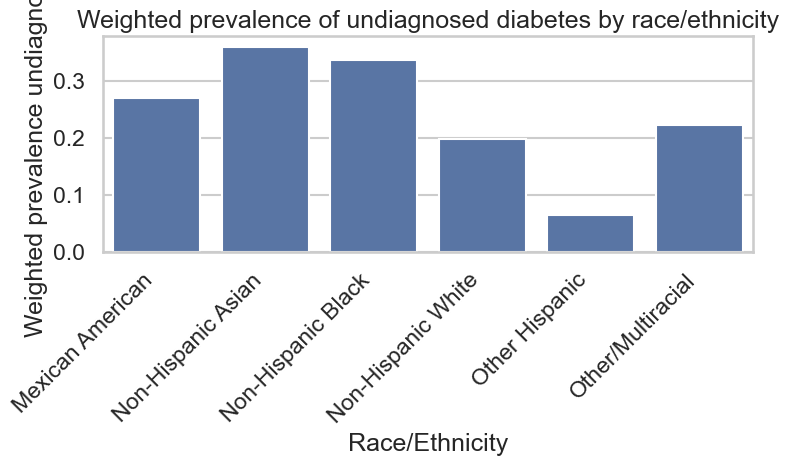

<Figure size 640x480 with 0 Axes>

In [60]:
# Weighted prevalence of undiagnosed diabetes by race/ethnicity
if race_ct is not None:
    plt.figure(figsize=(8, 5))
    sns.barplot(data=race_ct, x="race_eth", y="wt_prev_undiag")
    plt.xticks(rotation=45, ha="right")
    plt.xlabel("Race/Ethnicity")
    plt.ylabel("Weighted prevalence undiagnosed")
    plt.title("Weighted prevalence of undiagnosed diabetes by race/ethnicity")
    plt.tight_layout()
    plt.show()
    plt.savefig("Weighted Prevalence of Undiagnosed Diabetes by Race.png")

### <span style="color: blue;">Comment</span>

This plot shows the weighted prevalence of undiagnosed diabetes by subgroup. The bar heights indicate estimated U.S. population proportions, not raw sample counts.

As can be seen, White people have among the lowest rates of undiagnosis (only second to Other Hispanic, which is likely due to small sample size). Asians, black people, and Mexican Americans have noticeably higher rates of undiagnosis.

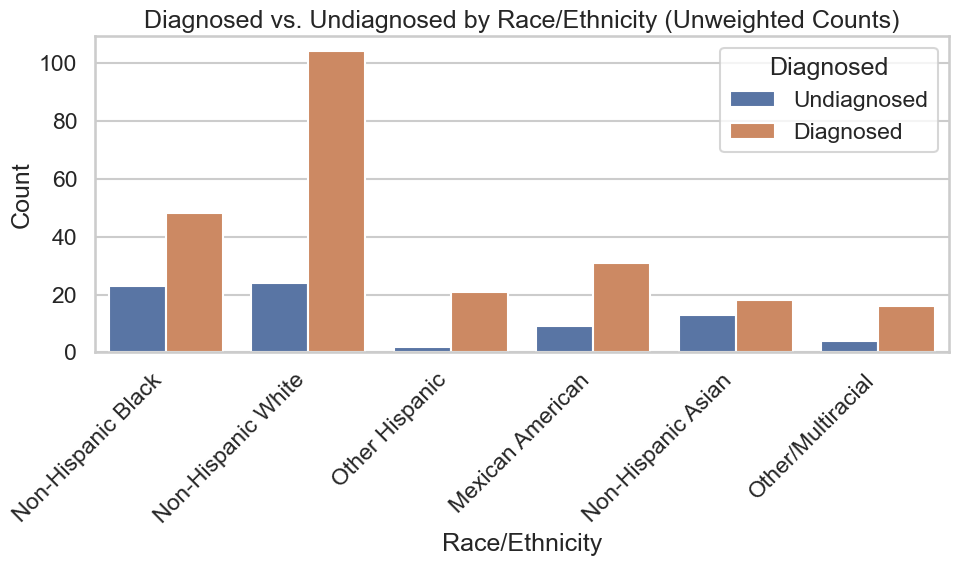

In [61]:
# Diagnosed vs undiagnosed counts by race/ethnicity (unweighted)

if "race_eth" in df_model.columns:
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df_model, x="race_eth", hue="y_diag")
    plt.xticks(rotation=45, ha="right")
    plt.xlabel("Race/Ethnicity")
    plt.ylabel("Count")
    plt.legend(title="Diagnosed", labels=["Undiagnosed", "Diagnosed"])
    plt.title("Diagnosed vs. Undiagnosed by Race/Ethnicity (Unweighted Counts)")
    plt.tight_layout()
    plt.show()

### <span style="color: blue;">Comment</span>

This plot shows unweighted counts of diagnosed vs. undiagnosed diabetes by race/ethnicity. The bar heights reflect proportions in our analytic sample. As expected, White people predominate in our unweighted analytic sample.

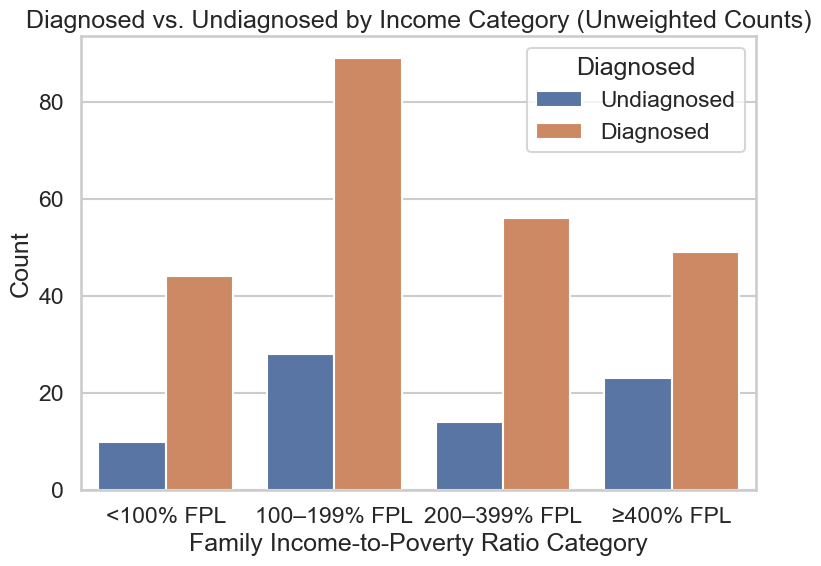

In [62]:
# Diagnosed vs undiagnosed counts by income (unweighted)

if "income_cat" in df_model.columns:
    order_inc = ["<100% FPL", "100–199% FPL", "200–399% FPL", "≥400% FPL"]
    plt.figure(figsize=(8, 6))
    sns.countplot(
        data=df_model, x="income_cat", hue="y_diag",
        order=[c for c in order_inc if c in df_model["income_cat"].unique()]
    )
    plt.xlabel("Family Income-to-Poverty Ratio Category")
    plt.ylabel("Count")
    plt.legend(title="Diagnosed", labels=["Undiagnosed", "Diagnosed"])
    plt.title("Diagnosed vs. Undiagnosed by Income Category (Unweighted Counts)")
    plt.tight_layout()
    plt.show()

### <span style="color: blue;">Comment</span>
The **income‑to‑poverty ratio** is the ratio of a family’s income to their poverty threshold. The poverty threshold is calculated by the Census Bureau using a complex formula.

Interpretation of ratio:
- Ratio = 1.0 → income at the poverty line  
- Ratio < 1.0 → income below the poverty line  
- Ratio > 1.0 → income above the poverty line

This plot shows unweighted counts of diagnosed vs. undiagnosed diabetes across income-to-poverty categories. These are raw counts, not adjusted for number of people in each category in our analytic sample. As a result, these should not be interpreted as an indication of any association, which will be analyzed later. 

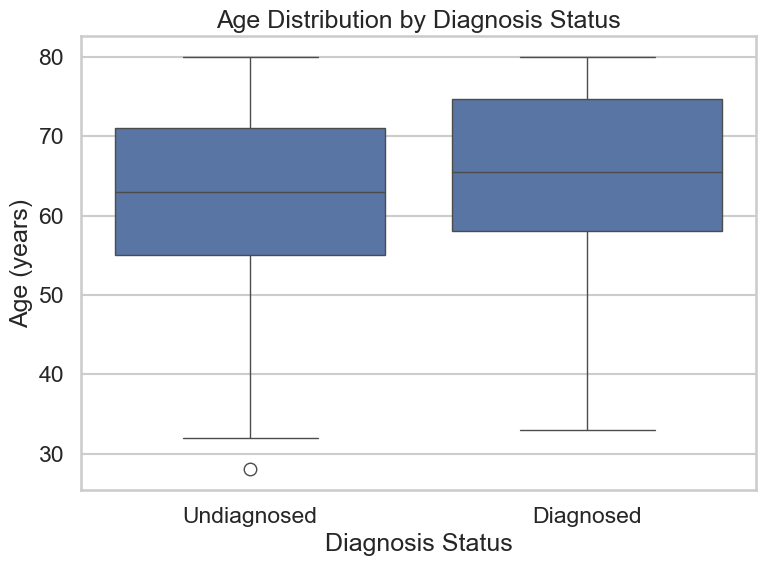

Unweighted Welch t-test: t = 2.16, p = 0.0330


In [63]:
# Age distribution by diagnosis status

plt.figure(figsize=(8, 6))
sns.boxplot(data=df_model, x="y_diag", y="age")
plt.xticks([0, 1], ["Undiagnosed", "Diagnosed"])
plt.xlabel("Diagnosis Status")
plt.ylabel("Age (years)")
plt.title("Age Distribution by Diagnosis Status")

plt.tight_layout()
plt.show()

# Check statisical significance
from scipy import stats

undiag = df_model.loc[df_model["y_diag"] == 0, "age"]
diag   = df_model.loc[df_model["y_diag"] == 1, "age"]

tstat, pval = stats.ttest_ind(diag, undiag, equal_var=False)
print(f"Unweighted Welch t-test: t = {tstat:.2f}, p = {pval:.4f}")


### <span style="color: blue;">Comment</span>

Diagnosed adults are older on average than undiagnosed adults. An unweighted Welch t-test (t = 2.16, p = 0.033) indicates that this age difference is statistically significant.

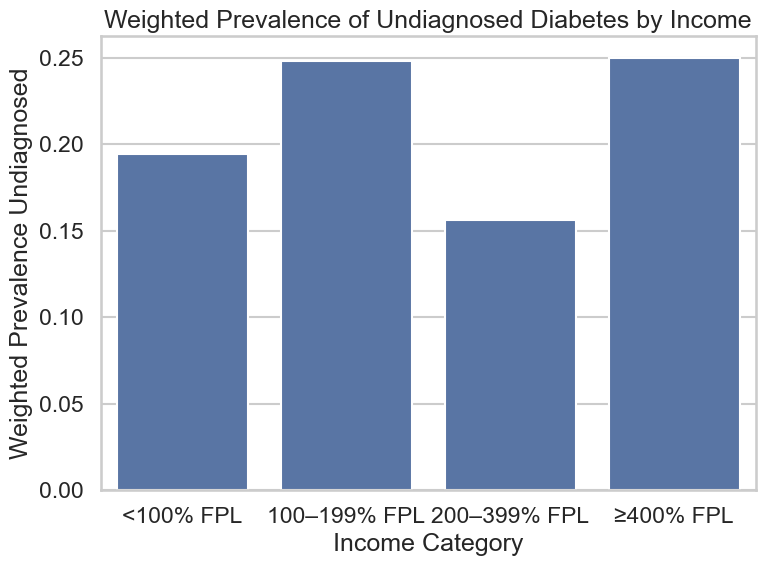

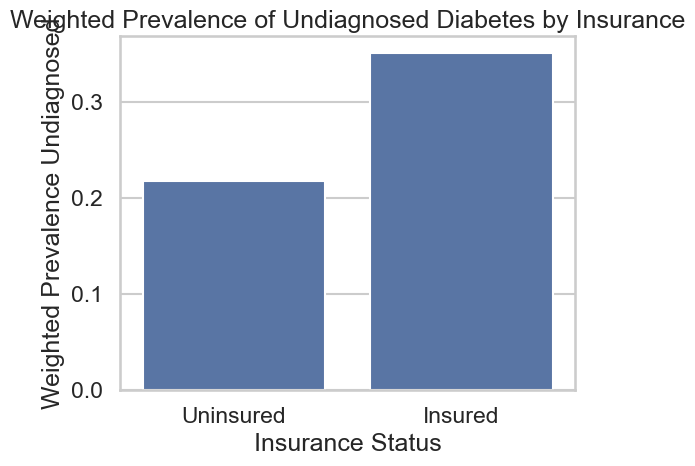

Unweighted chi-square (insurance): p = 0.358


In [64]:
# Weighted undiagnosed prevalence by income and insurance

if inc_ct is not None:
    inc_ct_sorted = inc_ct.sort_values("wt_prev_undiag")
    plt.figure(figsize=(8, 6))
    sns.barplot(
        data=inc_ct_sorted,
        x="income_cat",
        y="wt_prev_undiag",
        order=[c for c in ["<100% FPL", "100–199% FPL", "200–399% FPL", "≥400% FPL"]
               if c in inc_ct_sorted["income_cat"].values]
    )
    plt.ylabel("Weighted Prevalence Undiagnosed")
    plt.xlabel("Income Category")
    plt.title("Weighted Prevalence of Undiagnosed Diabetes by Income")
    plt.tight_layout()
    plt.show()

if ins_ct is not None:
    ins_ct_sorted = ins_ct.sort_values("wt_prev_undiag")
    plt.figure(figsize=(6, 5))
    sns.barplot(data=ins_ct_sorted, x="insured", y="wt_prev_undiag")
    plt.xticks([0, 1], ["Uninsured", "Insured"])
    plt.ylabel("Weighted Prevalence Undiagnosed")
    plt.xlabel("Insurance Status")
    plt.title("Weighted Prevalence of Undiagnosed Diabetes by Insurance")
    plt.tight_layout()
    plt.show()

from scipy.stats import chi2_contingency

ct_ins = pd.crosstab(df_model["insured"], df_model["y_diag"])
chi2_ins, p_ins, dof_ins, exp_ins = chi2_contingency(ct_ins)
print(f"Unweighted chi-square (insurance): p = {p_ins:.3f}")

### <span style="color: blue;">Comment</span>

Weighted undiagnosed prevalence does not vary monotonically by income. Furthermore, the estimate for insured adults appears higher, but this is based on a very small unweighted sample, so that insurance comparison is not significant (reflected by the non-significant p-value).

**EDA summary:**

- Among adults meeting biomarker criteria of diabetes, approximately **78%** are diagnosed and **22%** remain undiagnosed (weighted).
- Undiagnosed adults are somewhat **younger** than diagnosed adults.
- Weighted bar plots show:
  - Higher **undetected diabetes prevalence** among some racial/ethnic minority groups (e.g., non‑Hispanic Asian and non‑Hispanic Black adults) relative to non‑Hispanic White adults.
  - Mixed patterns by **income**, with some evidence of higher undiagnosed prevalence in certain lower‑ and middle‑income groups.
  - Non-significant differences by **insurance status**, likely due to the insured subgroup's low sample size.

These descriptive findings hint at the role of access to care and socioeconomic status in awareness of diabetes status. This relationship will be examined more formally using regression models.

### First Analysis – Survey‑Weighted Logistic Regression on Underdiagnosis

We next formally estimate associations between non‑clinical variables and the odds of being **undiagnosed** among biomarker‑positive adults using survey‑weighted logistic regression.

**Notes:**
- Outcome: `undiagnosed = 1 - y_diag` (1 = undiagnosed and 0 = diagnosed)
- Hypothesized predictors: age, sex, race/ethnicity, education, income, insurance, usual source of care, last checkup, smoking, alcohol, physical activity.
- Due to missingness, the final model is trained and tested on a subset of our analytic sample that may not be fully representative of the national population.
- We use NHANES survey weights in a logistic regression model (GLM with binomial family and logit link) to obtain estimates that are nationally representative

In [65]:
# Prepare design matrix for regression

df_model["undiagnosed"] = 1 - df_model["y_diag"]

X = df_model[available_predictors].copy()
y = df_model["undiagnosed"]
w = df_model["weight"]

# One-hot encode categorical variables
cat_vars = []
for var in ["sex", "race_eth", "education", "income_cat", "last_checkup"]:
    if (var in X.columns) and (X[var].dtype == "O"):
        cat_vars.append(var)

X_dummies = pd.get_dummies(X, columns=cat_vars, drop_first=True)
X_const = sm.add_constant(X_dummies)

print("Design matrix shape:", X_const.shape)
X_const.head()

Design matrix shape: (313, 18)


,const,age,insured,current_smoker,phys_active,sex_Male,race_eth_Non-Hispanic Asian,race_eth_Non-Hispanic Black,race_eth_Non-Hispanic White,race_eth_Other Hispanic,race_eth_Other/Multiracial,education_<9th grade,education_College grad or above,education_HS/GED,education_Some college/AA,income_cat_200–399% FPL,income_cat_<100% FPL,income_cat_≥400% FPL
0,1.0,54.0,0.0,0.0,0,False,False,True,False,False,False,False,False,False,True,False,False,False
2,1.0,55.0,0.0,1.0,0,False,False,False,True,False,False,True,False,False,False,False,True,False
5,1.0,61.0,0.0,0.0,1,True,False,False,False,True,False,False,True,False,False,False,False,False
6,1.0,80.0,0.0,0.0,1,True,False,False,True,False,False,False,False,True,False,True,False,False
7,1.0,66.0,0.0,0.0,0,False,False,False,True,False,False,False,True,False,False,False,False,True


### <span style="color: blue;">Comment</span>

To fit logistic regression, we must first build a **design matrix**. This is a numeric table where each row is a person and each column is a predictor. 

Categorical predictors (e.g., sex, race, education, income) are converted to multiple 0/1 indicator columns using **one‑hot encoding** (i.e. one column is sex = Male, and the values represent booleans). This is because logistic regression can only take numeric values.

In [66]:
# Convert to numpy arrays with a fixed float dtype
X_np = X_const.to_numpy(dtype=float)
y_np = y.to_numpy(dtype=float)
w_np = w.to_numpy(dtype=float)

print("X_np shape:", X_np.shape, "dtype:", X_np.dtype)
print("y_np shape:", y_np.shape, "dtype:", y_np.dtype)
print("w_np shape:", w_np.shape, "dtype:", w_np.dtype)

# Fit GLM
glm_binom = sm.GLM(
    y_np,
    X_np,
    family=sm.families.Binomial(),
    freq_weights=w_np
)
glm_res = glm_binom.fit()

print(glm_res.summary())

X_np shape: (313, 18) dtype: float64
y_np shape: (313,) dtype: float64
w_np shape: (313,) dtype: float64
                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:                  313
Model:                            GLM   Df Residuals:              10967084.13
Model Family:                Binomial   Df Model:                           17
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -5.2817e+06
Date:                Wed, 18 Mar 2026   Deviance:                   1.0563e+07
Time:                        19:41:58   Pearson chi2:                 1.12e+07
No. Iterations:                     6   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
--------------------------

In [67]:
# Coefficient names from the original design matrix
coef_names = X_const.columns.to_list()

# Extract parameters, CIs, and p-values
params = glm_res.params          # 1D array, length k
conf = glm_res.conf_int()        # usually array of shape (k, 2) now
pvals = glm_res.pvalues          # 1D array, length k

print("params length:", len(params))
print("conf shape:", getattr(conf, "shape", None))
print("pvals length:", len(pvals))

import numpy as np
import pandas as pd

if isinstance(conf, np.ndarray):
    conf_lower = conf[:, 0]
    conf_upper = conf[:, 1]
else:
    # If it's a DataFrame/Series, use column indexing
    conf_lower = conf.iloc[:, 0].values
    conf_upper = conf.iloc[:, 1].values

or_df = pd.DataFrame({
    "variable": coef_names,
    "OR": np.exp(params),
    "CI_lower": np.exp(conf_lower),
    "CI_upper": np.exp(conf_upper),
    "p_value": pvals
})

or_df = or_df.sort_values("OR", ascending=False)
or_df.head(25)

params length: 18
conf shape: (18, 2)
pvals length: 18


,variable,OR,CI_lower,CI_upper,p_value
2,insured,2.206978,2.189550,2.224544,0.000000e+00
12,education_College grad or above,2.136611,2.123736,2.149563,0.000000e+00
6,race_eth_Non-Hispanic Asian,1.805209,1.790532,1.820006,0.000000e+00
0,const,1.662966,1.647444,1.678634,0.000000e+00
7,race_eth_Non-Hispanic Black,1.537638,1.527176,1.548171,0.000000e+00
13,education_HS/GED,1.417446,1.410061,1.424870,0.000000e+00
3,current_smoker,1.286896,1.282063,1.291747,0.000000e+00
11,education_<9th grade,1.219747,1.209238,1.230348,0.000000e+00
4,phys_active,1.083830,1.080214,1.087459,0.000000e+00
1,age,0.978614,0.978491,0.978737,0.000000e+00


## **Interpretation:**
**Note**: Logistic regression mutually adjusts for each variable in the analysis. Thus, everything reported in the table represent independent effects not due to confounding between each variable.
Key results:
- **Age and sex**
  - Each additional year of age is associated with slightly **lower** odds of being undiagnosed (OR ≈ 0.98). This is consistent with the intuitive idea that older adults are more likely to know their diagnosis, simply due to having had more time to discover it or due to older people getting more thorough tests.
  - **Men** have lower odds of being undiagnosed than women (OR ≈ 0.69 for male vs. female), after adjustment.

- **Race/ethnicity**  
  (relative to Mexican American adults, the reference group)
  - **Non‑Hispanic Asian** adults have higher odds of being undiagnosed (OR ≈ 1.81).
  - **Non‑Hispanic Black** adults also have higher odds (OR ≈ 1.54).
  - **Non‑Hispanic White** adults have lower odds (OR ≈ 0.59).
  - **Other Hispanic** adults have much lower odds (OR ≈ 0.17).
  - Adults classified as **Other/Multiracial** have slightly lower odds (OR ≈ 0.87).

- **Education**  
  (relative to 9–11th grade)
  - **College graduates** have substantially higher odds of being undiagnosed (OR ≈ 2.14).
  - Those with **HS/GED** (OR ≈ 1.42) and **<9th grade** (OR ≈ 1.22) also show higher odds.
  - Those with **some college/AA** have lower odds (OR ≈ 0.55).
  - Overall, patterns by education are mixed and somewhat counterintuitive.

- **Income**  
  (relative to 100–199% FPL)
  - Adults with **<100% FPL** (OR ≈ 0.46), **200–399% FPL** (OR ≈ 0.60), and **≥400% FPL** (OR ≈ 0.85) all show **lower** odds of being undiagnosed.
  - Thus, the 100–199% FPL group appears to have the highest odds of underdiagnosis, and the pattern by income is not monotonic.

- **Insurance**
  - Being **insured** is associated with *higher* odds of being undiagnosed (OR ≈ 2.21), which is conunterintuitive. This estimate is based on only a small number of insured adults in the analytic sample and should be interpreted very cautiously.

- **Behavioral factors**
  - **Current smokers** have higher odds of being undiagnosed (OR ≈ 1.29).
  - Being classified as **physically active** is also associated with slightly higher odds (OR ≈ 1.08), which is counterintuitive..

Taken together, the adjusted model shows clear differences in underdiagnosis by age, sex, and race/ethnicity. Patterns by income, education, and insurance status are more complex and in some cases counterintuitive, likely reflecting small sample sizes and residual confounding.

### Second Analysis You Did – Predictive Models for Diabetes Awareness

We now move on to a predictive modeling task: can non‑clinical variables predict whether biomarker‑positive adults **know** about their diabetes (diagnosed vs. undiagnosed)?

- Outcome: `y_diag` (1 = diagnosed, 0 = undiagnosed).
- Predictors: same non‑clinical features (`X_dummies`).
- Models:
  - Logistic Regression
  - Random Forest (base and tuned via grid search)
- Metrics:
  - AUC (Area Under the ROC Curve),
  - Sensitivity, specificity, PPV, NPV at threshold 0.5,
  - Brier score and calibration plot.

We also include a small hyperparameter search for the random forest and a learning curve for logistic regression to examine how performance scales with data.

In [68]:
# Train-test split

X_clf = X_dummies.copy()
y_clf = df_model["y_diag"]
w_clf = df_model["weight"]

X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
    X_clf, y_clf, w_clf,
    test_size=0.3,
    stratify=y_clf,
    random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (219, 17)
Test shape: (94, 17)


In [69]:
# Base models

log_reg = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    solver="lbfgs"
)

rf_base = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=20,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

log_reg.fit(X_train, y_train, sample_weight=w_train)
rf_base.fit(X_train, y_train, sample_weight=w_train)

,n_estimators,300
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,20
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### <span style="color: blue;">Comment</span>

This sets up baseline predictive models - logistic regression and random forest. We use NHANES survey weights as sample weights and `class_weight="balanced"` to account for class imbalance. The random forest uses 300 trees and a relatively large minimum leaf size to reduce overfitting on this small dataset.

In [70]:
# Evaluation helper

def evaluate_model(model, X_tr, y_tr, w_tr, X_te, y_te, w_te, name="Model", threshold=0.5):
    y_tr_prob = model.predict_proba(X_tr)[:, 1]
    y_te_prob = model.predict_proba(X_te)[:, 1]

    auc_tr = roc_auc_score(y_tr, y_tr_prob, sample_weight=w_tr)
    auc_te = roc_auc_score(y_te, y_te_prob, sample_weight=w_te)

    print(f"{name} AUC (train): {auc_tr:.3f}")
    print(f"{name} AUC (test):  {auc_te:.3f}")

    fpr, tpr, _ = roc_curve(y_te, y_te_prob, sample_weight=w_te)
    plt.figure(figsize=(6, 6))
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc_te:.2f})")
    plt.plot([0, 1], [0, 1], "k--")
    plt.xlabel("1 - Specificity")
    plt.ylabel("Sensitivity")
    plt.title(f"ROC Curve: {name}")
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.show()

    y_te_pred = (y_te_prob >= threshold).astype(int)
    cm = confusion_matrix(y_te, y_te_pred)
    print("Confusion matrix (rows=True, cols=Pred):")
    print(cm)

    if cm.shape == (2, 2):
        tn, fp, fn, tp = cm.ravel()
        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else np.nan
        specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan
        ppv = precision_score(y_te, y_te_pred) if (tp + fp) > 0 else np.nan
        npv = tn / (tn + fn) if (tn + fn) > 0 else np.nan
    else:
        sensitivity = specificity = ppv = npv = np.nan

    print(f"Sensitivity (Recall): {sensitivity:.3f}")
    print(f"Specificity:          {specificity:.3f}")
    print(f"PPV (Precision):      {ppv:.3f}")
    print(f"NPV:                  {npv:.3f}")

    brier = brier_score_loss(y_te, y_te_prob, sample_weight=w_te)
    print(f"Brier score (lower=better): {brier:.3f}")

    return {
        "auc_train": auc_tr,
        "auc_test": auc_te,
        "sensitivity": sensitivity,
        "specificity": specificity,
        "ppv": ppv,
        "npv": npv,
        "brier": brier
    }

Logistic Regression AUC (train): 0.720
Logistic Regression AUC (test):  0.452


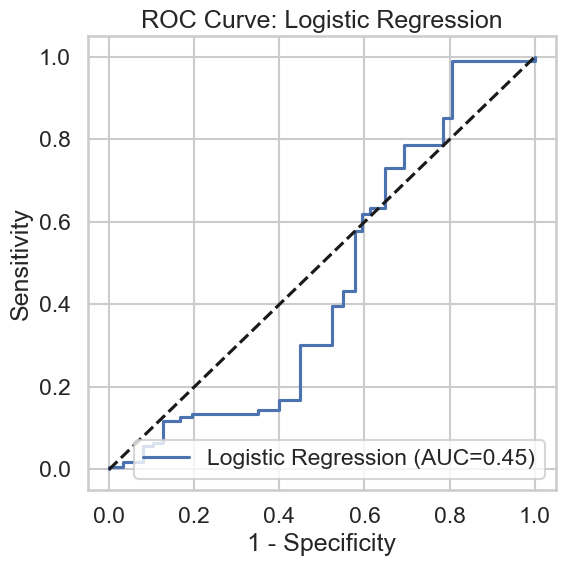

Confusion matrix (rows=True, cols=Pred):
[[ 9 14]
 [24 47]]
Sensitivity (Recall): 0.662
Specificity:          0.391
PPV (Precision):      0.770
NPV:                  0.273
Brier score (lower=better): 0.292
Random Forest (Base) AUC (train): 0.745
Random Forest (Base) AUC (test):  0.557


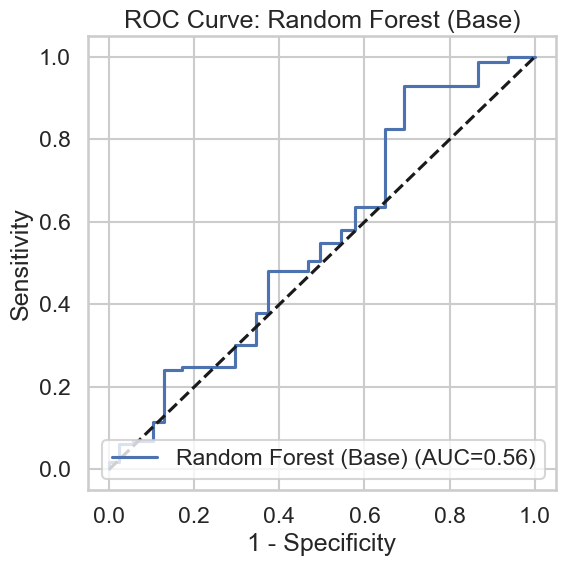

Confusion matrix (rows=True, cols=Pred):
[[ 9 14]
 [23 48]]
Sensitivity (Recall): 0.676
Specificity:          0.391
PPV (Precision):      0.774
NPV:                  0.281
Brier score (lower=better): 0.239


({'auc_train': 0.7203091107540602,
  'auc_test': 0.45174594567840737,
  'sensitivity': np.float64(0.6619718309859155),
  'specificity': np.float64(0.391304347826087),
  'ppv': 0.7704918032786885,
  'npv': np.float64(0.2727272727272727),
  'brier': 0.29202672736644575},
 {'auc_train': 0.7452428211440444,
  'auc_test': 0.5567231126417214,
  'sensitivity': np.float64(0.676056338028169),
  'specificity': np.float64(0.391304347826087),
  'ppv': 0.7741935483870968,
  'npv': np.float64(0.28125),
  'brier': 0.23871995574205346})

In [71]:
# Evaluate base Logistic Regression and Random Forest

metrics_log = evaluate_model(
    log_reg, X_train, y_train, w_train, X_test, y_test, w_test,
    name="Logistic Regression", threshold=0.5
)

metrics_rf_base = evaluate_model(
    rf_base, X_train, y_train, w_train, X_test, y_test, w_test,
    name="Random Forest (Base)", threshold=0.5
)

metrics_log, metrics_rf_base

### <span style="color: blue;">Comment</span>

We evaluated each model using several metrics. We calculated AUC, confusion matrix metrics (using a 0.5 threshold), and Brier scores, which measure how close the model's predicted probabilities are to true outcomes (lower being better). Lastly, we plot ROC curves.

For logistic regression, test performance is weak. The model has a sensitivity of 0.676 but a low specificity of 0.391, indicating that it identifies many undiagnosed individuals but also produces many false positives. The PPV is 0.774, while the NPV is much lower at 0.281, which means negative predictions are not very reliable. The Brier score of 0.239 also suggests limited accuracy in the predicted probabilities.

Overall, logistic regression shows moderate performance on the training set (AUC ≈ 0.72) but poor generalization to the test set (AUC ≈ 0.45), indicating that non-clinical variables alone are not very effective for predicting diabetes awareness.

Best parameters: {'max_depth': None, 'min_samples_leaf': 20}
Best CV AUC: 0.5058533855744538
Random Forest (Tuned) AUC (train): 0.745
Random Forest (Tuned) AUC (test):  0.557


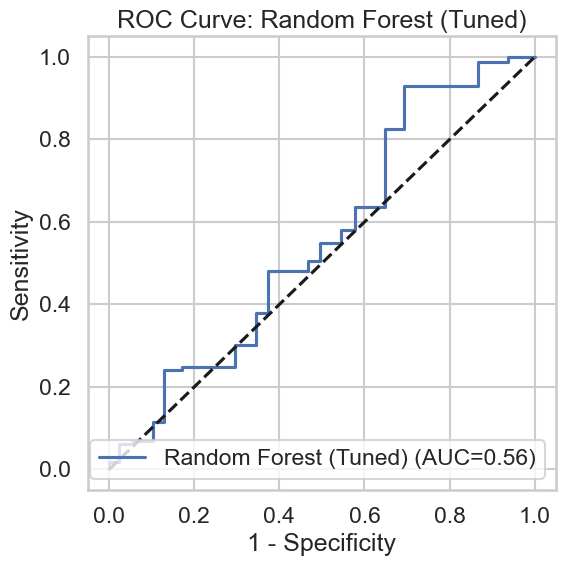

Confusion matrix (rows=True, cols=Pred):
[[ 9 14]
 [23 48]]
Sensitivity (Recall): 0.676
Specificity:          0.391
PPV (Precision):      0.774
NPV:                  0.281
Brier score (lower=better): 0.239


{'auc_train': 0.7452428211440444,
 'auc_test': 0.5567231126417214,
 'sensitivity': np.float64(0.676056338028169),
 'specificity': np.float64(0.391304347826087),
 'ppv': 0.7741935483870968,
 'npv': np.float64(0.28125),
 'brier': 0.23871995574205343}

In [72]:
# Hyperparameter tuning for Random Forest

param_grid = {
    "max_depth": [None, 5, 10],
    "min_samples_leaf": [5, 10, 20]
}

rf_for_grid = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

grid = GridSearchCV(
    rf_for_grid,
    param_grid,
    scoring="roc_auc",
    cv=3,
    n_jobs=-1
)

grid.fit(X_train, y_train, sample_weight=w_train)

print("Best parameters:", grid.best_params_)
print("Best CV AUC:", grid.best_score_)

rf_tuned = grid.best_estimator_

metrics_rf_tuned = evaluate_model(
    rf_tuned, X_train, y_train, w_train, X_test, y_test, w_test,
    name="Random Forest (Tuned)", threshold=0.5
)

metrics_rf_tuned

### <span style="color: blue;">Comment</span>

We perform hyperparameter optimization to try to improve the performance of our model using Grid Search.

We use built-in **regularization** to keep models from overfitting. This is done with an L2 penalty for logistic regression and by limiting random forest hyperparameters. We also set `class_weight="balanced"` so that misclassifying undiagnosed adults (the minority class) is penalized more heavily, encouraging the models to pay attention to underdiagnosis rather than defaulting to the majority diagnosed class.

We tuned the random forest over `max_depth` and `min_samples_leaf` using 3‑fold CV with AUC as the scoring metric. The best setting (`max_depth=None`, `min_samples_leaf=20`) yields a modest cross‑validated AUC (~0.51) and a test AUC of ~0.56, only slightly better than chance, indicating limited predictive value of non‑clinical variables for diabetes awareness.

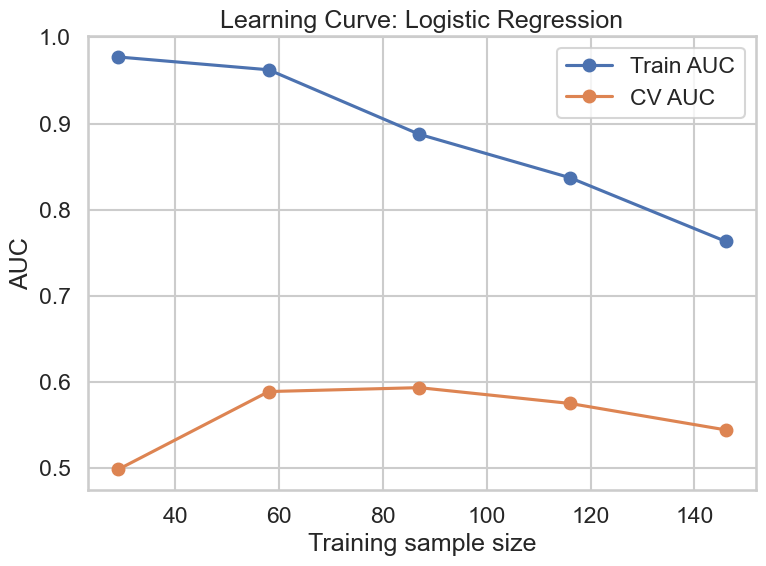

In [73]:
# Learning curve for Logistic Regression

train_sizes, train_scores, val_scores = learning_curve(
    log_reg,
    X_train,
    y_train,
    cv=3,
    scoring="roc_auc",
    n_jobs=-1,
    train_sizes=np.linspace(0.2, 1.0, 5)
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_mean, "o-", label="Train AUC")
plt.plot(train_sizes, val_mean, "o-", label="CV AUC")
plt.xlabel("Training sample size")
plt.ylabel("AUC")
plt.title("Learning Curve: Logistic Regression")
plt.legend()
plt.tight_layout()
plt.show()

### <span style="color: blue;">Comment</span>

The learning curve shows that test performance plateaus in the mid‑0.5 AUC range and does not improve much with more training data. This suggests that the non‑clinical predictors we have chosen have limited signal for predicting diabetes awareness. The gap between training and test curves indicates some overfitting despite regularization and class balancing.

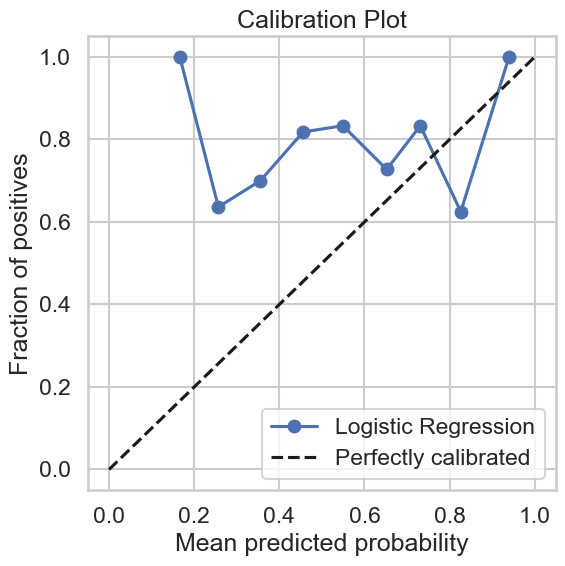

In [74]:
# Calibration plot for Logistic Regression

y_test_prob_log = log_reg.predict_proba(X_test)[:, 1]
prob_true, prob_pred = calibration_curve(y_test, y_test_prob_log, n_bins=10)

plt.figure(figsize=(6, 6))
plt.plot(prob_pred, prob_true, "o-", label="Logistic Regression")
plt.plot([0, 1], [0, 1], "k--", label="Perfectly calibrated")
plt.xlabel("Mean predicted probability")
plt.ylabel("Fraction of positives")
plt.title("Calibration Plot")
plt.legend()
plt.tight_layout()
plt.show()

### <span style="color: blue;">Comment</span>

The calibration plot indicates that predicted probabilities are only moderately calibrated: the model tends to over‑estimate risk for some groups and under‑estimate it for others, consistent with the modest Brier scores.

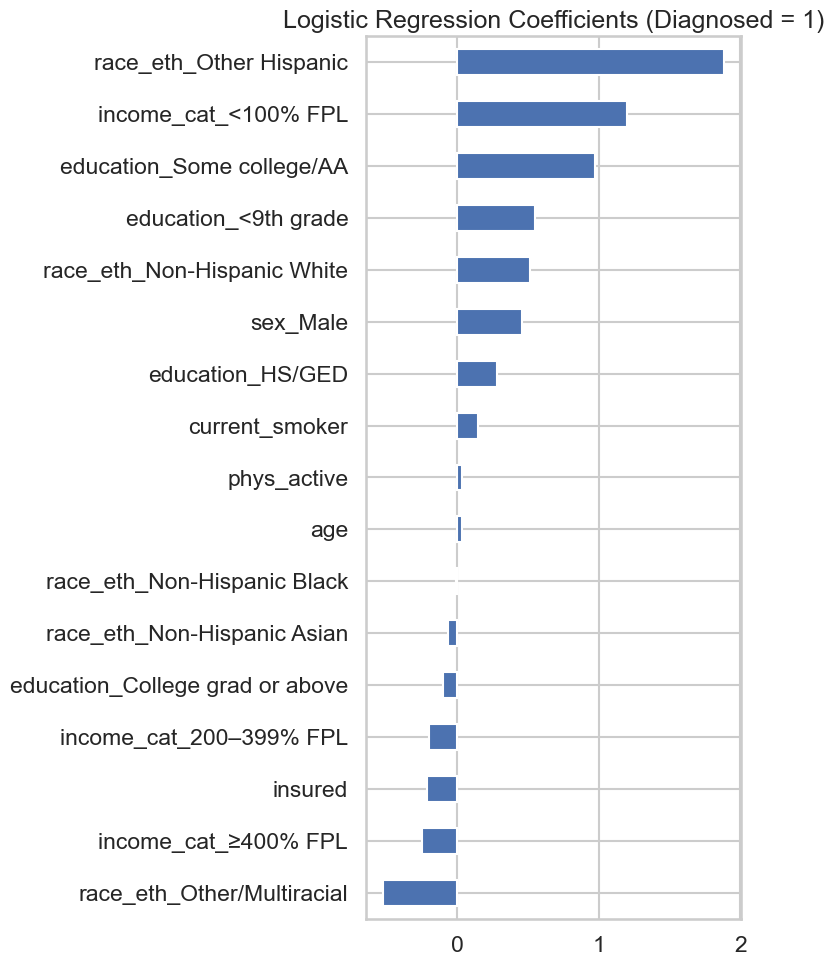


Logistic Regression coefficients (sorted, Diagnosed = 1):
                                 coefficient  odds_ratio
race_eth_Other Hispanic                1.884       6.581
income_cat_<100% FPL                   1.197       3.311
education_Some college/AA              0.974       2.648
education_<9th grade                   0.546       1.726
race_eth_Non-Hispanic White            0.515       1.674
sex_Male                               0.457       1.580
education_HS/GED                       0.279       1.322
current_smoker                         0.144       1.155
phys_active                            0.036       1.036
age                                    0.035       1.035
race_eth_Non-Hispanic Black           -0.011       0.989
race_eth_Non-Hispanic Asian           -0.065       0.937
education_College grad or above       -0.102       0.903
income_cat_200–399% FPL               -0.200       0.819
insured                               -0.211       0.810
income_cat_≥400% FPL         

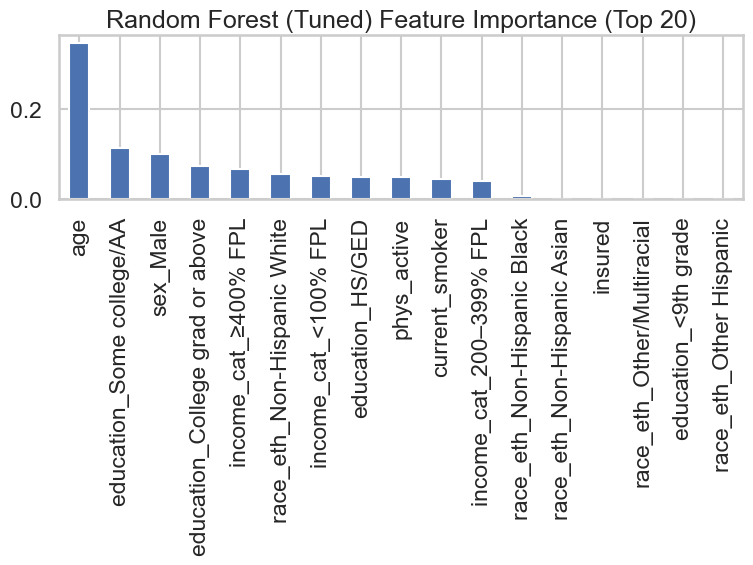


Random Forest feature importances (sorted):
                                 importance
age                                   0.345
education_Some college/AA             0.113
sex_Male                              0.101
education_College grad or above       0.074
income_cat_≥400% FPL                  0.067
race_eth_Non-Hispanic White           0.057
income_cat_<100% FPL                  0.052
education_HS/GED                      0.050
phys_active                           0.049
current_smoker                        0.044
income_cat_200–399% FPL               0.041
race_eth_Non-Hispanic Black           0.008
race_eth_Non-Hispanic Asian           0.000
insured                               0.000
race_eth_Other/Multiracial            0.000
education_<9th grade                  0.000
race_eth_Other Hispanic               0.000


In [75]:
# Feature importance: Logistic Regression and Random Forest (tuned)

# --- Logistic Regression coefficients ---

coef_series = pd.Series(log_reg.coef_[0], index=X_train.columns)

# Plot
plt.figure(figsize=(8, 10))
coef_series.sort_values().plot(kind="barh")
plt.title("Logistic Regression Coefficients (Diagnosed = 1)")
plt.tight_layout()
plt.show()

# Also print as a sorted table (with odds ratios)
coef_df = pd.DataFrame({
    "coefficient": coef_series,
    "odds_ratio": np.exp(coef_series)
}).sort_values("coefficient", ascending=False)

print("\nLogistic Regression coefficients (sorted, Diagnosed = 1):")
print(coef_df.to_string(float_format="%.3f"))


# --- Random Forest feature importances ---

rf_importances = pd.Series(rf_tuned.feature_importances_, index=X_train.columns)

# Plot
plt.figure(figsize=(8, 6))
rf_importances.sort_values(ascending=False).head(20).plot(kind="bar")
plt.title("Random Forest (Tuned) Feature Importance (Top 20)")
plt.tight_layout()
plt.show()

# Also print full sorted importances
rf_imp_df = rf_importances.sort_values(ascending=False).to_frame(name="importance")

print("\nRandom Forest feature importances (sorted):")
print(rf_imp_df.to_string(float_format="%.3f"))

### <span style="color: blue;">Comment</span>

Random forest feature importance indicates that age is by far the dominant predictor of diabetes awareness, followed by education, sex, income, and (to a lesser extent) physical activity and smoking. Race/ethnicity and insurance status contribute very little. This is consistent with the overall low model performance and suggests that non‑clinical variables alone provide limited signal for classifying undiagnosed cases.

**Interpretation:**

- **Overall performance:** Logistic regression achieved an AUC of about **0.72** on the training set but only about **0.45** on the test set. The tuned random forest achieved AUCs of about **0.75** (train) and **0.56** (test). These test‑set values are only slightly above chance (0.50). This indicates that the model performance is poor and non‑clinical predictors alone have limited ability to predict diabetes awareness in this sample.

- **Sensitivity/specificity trade‑off:** At a threshold of 0.5, both models show modest and imperfect sensitivity and specificity; neither identifies undiagnosed cases especially well.

- **Calibration:** Calibration plots and Brier scores are consistent with the weak discrimination: predicted probabilities deviate from observed proportions.

- 
- **Hyperparameter tuning:** Tuning the random forest over `max_depth` and `min_samples_leaf` yields a best cross‑validated AUC of about **0.51** and a test AUC of about **0.56**. This is only a small improvement over the untuned model. This suggests that model choice and hyperparameters are not the main bottleneck, but instead that the predictors simply do not carry much signal for this task.

- **Feature importance:** 
  - For the tuned random forest, **age** is by far the most important predictor, followed by **education**, **sex**, **income**, and to a lesser extent **physical activity** and **smoking**. Several race/ethnicity and insurance indicators have near‑zero importance.
  - These results suggest that while age and SES‑related factors are associated with awareness (as evidenced by the Odds Ratios earlier), they do not provide enough information to reliably classify which biomarker‑positive adults are undiagnosed.

Overall, the predictive models perform only slightly better than chance on held‑out data, indicating that **H3** (strong predictive performance using non‑clinical features alone) is not well supported in this small NHANES subset.

### Third Analysis You Did – Fairness and Subgroup Performance

Finally, we investigate **fairness** by evaluating model performance across race/ethnicity and income subgroups.

We will use the tuned random forest (our best performing model) and compute the following for each subgroup on the test set:

- AUC (weighted),
- Sensitivity at threshold 0.5.

These subgroup metrics will be illustrated through figures to detect performance gaps.

In [76]:
# Subgroup metrics helper

def subgroup_metrics(model, X, y, w, group_series, group_name="group", threshold=0.5, min_n=20):
    probs = model.predict_proba(X)[:, 1]
    results = []

    for g in sorted(group_series.dropna().unique()):
        mask = (group_series == g)
        if mask.sum() < min_n:
            continue

        y_g = y[mask]
        w_g = w[mask]
        p_g = probs[mask]

        try:
            auc_g = roc_auc_score(y_g, p_g, sample_weight=w_g)
        except ValueError:
            auc_g = np.nan

        y_pred_g = (p_g >= threshold).astype(int)
        cm = confusion_matrix(y_g, y_pred_g)
        if cm.shape == (2, 2):
            tn, fp, fn, tp = cm.ravel()
            sensitivity = tp / (tp + fn) if (tp + fn) > 0 else np.nan
        else:
            sensitivity = np.nan

        results.append({
            group_name: g,
            "N": int(mask.sum()),
            "AUC": auc_g,
            "Sensitivity": sensitivity
        })

    return pd.DataFrame(results).sort_values(group_name)

In [77]:
# Prepare subgroup labels for test set

race_test = df_model.loc[X_test.index, "race_eth"] if "race_eth" in df_model.columns else None
inc_test  = df_model.loc[X_test.index, "income_cat"] if "income_cat" in df_model.columns else None

In [78]:
# Subgroup performance by race and income (Random Forest tuned)

if race_test is not None:
    race_perf_rf = subgroup_metrics(
        rf_tuned, X_test, y_test, w_test,
        race_test, group_name="race_eth", threshold=0.5
    )
else:
    race_perf_rf = None

if inc_test is not None:
    inc_perf_rf = subgroup_metrics(
        rf_tuned, X_test, y_test, w_test,
        inc_test, group_name="income_cat", threshold=0.5
    )
else:
    inc_perf_rf = None

race_perf_rf, inc_perf_rf

(             race_eth   N       AUC  Sensitivity
 0  Non-Hispanic Black  22  0.741738     0.666667
 1  Non-Hispanic White  41  0.256013     0.771429,
      income_cat   N       AUC  Sensitivity
 0  100–199% FPL  39  0.538393     0.700000
 1  200–399% FPL  23  0.782359     0.800000
 2     ≥400% FPL  23  0.672602     0.470588)

### <span style="color: blue;">Comment</span>

Subgroup performance for the tuned random forest varies by race/ethnicity and income. The model shows higher AUC in non-Hispanic Black and mid-income groups and very low AUC in non-Hispanic White adults. However, the sample size for each subgroup is small (N ≈ 20–40), so these differences are small and should be interpreted with caution


Subgroup performance by race/ethnicity (Random Forest, test set):
          race_eth  N   AUC  Sensitivity
Non-Hispanic Black 22 0.742        0.667
Non-Hispanic White 41 0.256        0.771


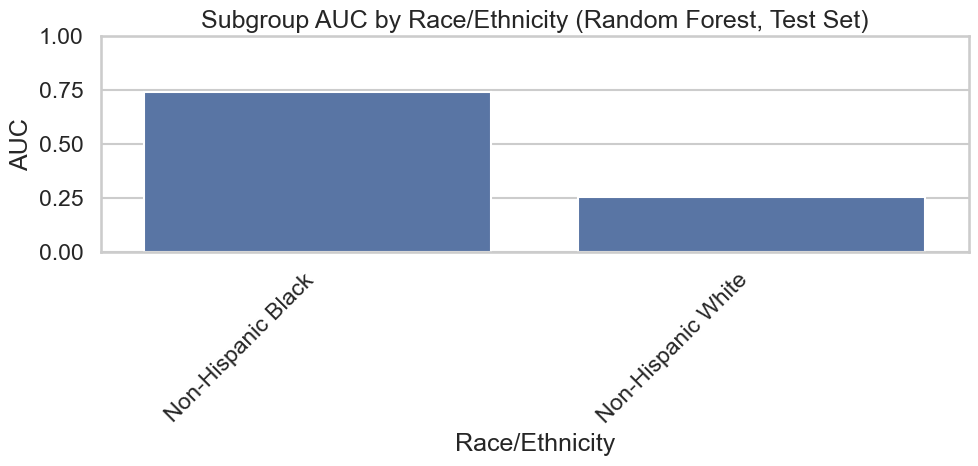

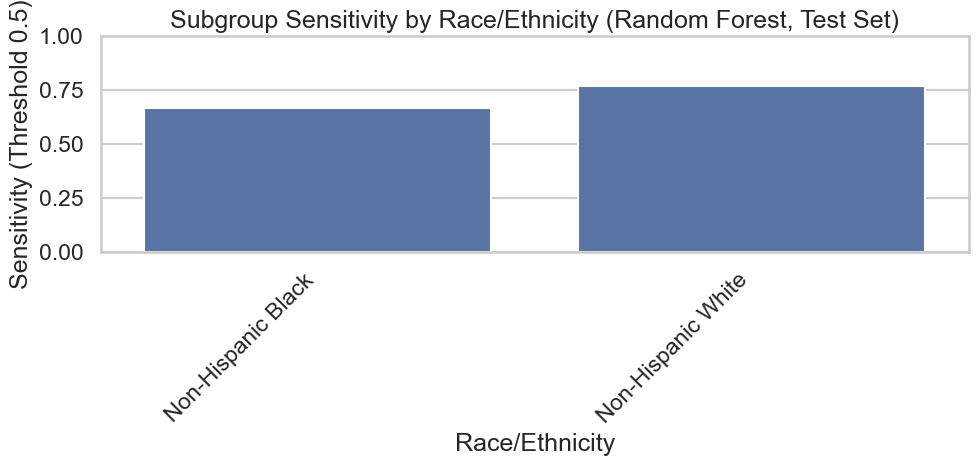

In [79]:
# Visualize subgroup AUC and sensitivity by race/ethnicity
if race_perf_rf is not None and not race_perf_rf.empty:
    # Round for prettier printing
    race_perf_print = race_perf_rf.copy()
    race_perf_print["AUC"] = race_perf_print["AUC"].round(3)
    race_perf_print["Sensitivity"] = race_perf_print["Sensitivity"].round(3)

    print("\nSubgroup performance by race/ethnicity (Random Forest, test set):")
    print(race_perf_print.to_string(index=False))

    # AUC plot
    plt.figure(figsize=(10, 5))
    sns.barplot(data=race_perf_rf, x="race_eth", y="AUC")
    plt.xticks(rotation=45, ha="right")
    plt.ylim(0, 1)
    plt.ylabel("AUC")
    plt.xlabel("Race/Ethnicity")
    plt.title("Subgroup AUC by Race/Ethnicity (Random Forest, Test Set)")
    plt.tight_layout()
    plt.show()

    # Sensitivity plot
    plt.figure(figsize=(10, 5))
    sns.barplot(data=race_perf_rf, x="race_eth", y="Sensitivity")
    plt.xticks(rotation=45, ha="right")
    plt.ylim(0, 1)
    plt.ylabel("Sensitivity (Threshold 0.5)")
    plt.xlabel("Race/Ethnicity")
    plt.title("Subgroup Sensitivity by Race/Ethnicity (Random Forest, Test Set)")
    plt.tight_layout()
    plt.show()

### <span style="color: blue;">Comment</span>

At first glance, the model appears to predict better for non-Hispanic Black adults than for non-Hispanic White adults (higher subgroup AUC), contrary to our hypothesis. Next we will test whether this apparent difference is statistically significant given the small subgroup sizes.

In [80]:
from sklearn.metrics import roc_auc_score
import numpy as np

def subgroup_auc_sens(model, X, y, w, group, label, threshold=0.5):
    """Compute AUC and sensitivity for one subgroup."""
    idx = (group == label)
    X_g = X[idx]
    y_g = y[idx]
    w_g = w[idx] if w is not None else None

    if y_g.nunique() < 2:
        return np.nan, np.nan  # cannot compute AUC/sens with one class only

    y_prob = model.predict_proba(X_g)[:, 1]
    auc = roc_auc_score(y_g, y_prob, sample_weight=w_g)

    y_pred = (y_prob >= threshold).astype(int)
    tp = ((y_pred == 1) & (y_g == 1)).sum()
    fn = ((y_pred == 0) & (y_g == 1)).sum()
    sens = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    return auc, sens


def bootstrap_diff_auc_sens(
    model, X, y, w, group, label1, label2,
    n_boot=2000, threshold=0.5, random_state=42
):
    rng = np.random.default_rng(random_state)

    # Indices for each group
    idx1 = np.where(group == label1)[0]
    idx2 = np.where(group == label2)[0]

    # Point estimates
    auc1, sens1 = subgroup_auc_sens(model, X, y, w, group, label1, threshold)
    auc2, sens2 = subgroup_auc_sens(model, X, y, w, group, label2, threshold)
    diff_auc_obs = auc1 - auc2
    diff_sens_obs = sens1 - sens2

    # Bootstrap
    boot_diffs_auc = []
    boot_diffs_sens = []

    for _ in range(n_boot):
        # resample within each group (unweighted bootstrap for simplicity)
        b_idx1 = rng.choice(idx1, size=len(idx1), replace=True)
        b_idx2 = rng.choice(idx2, size=len(idx2), replace=True)

        # group 1
        y1 = y.iloc[b_idx1]
        X1 = X.iloc[b_idx1]
        w1 = w.iloc[b_idx1] if w is not None else None
        y1_prob = model.predict_proba(X1)[:, 1]
        auc1_b = roc_auc_score(y1, y1_prob, sample_weight=w1)
        y1_pred = (y1_prob >= threshold).astype(int)
        tp1 = ((y1_pred == 1) & (y1 == 1)).sum()
        fn1 = ((y1_pred == 0) & (y1 == 1)).sum()
        sens1_b = tp1 / (tp1 + fn1) if (tp1 + fn1) > 0 else np.nan

        # group 2
        y2 = y.iloc[b_idx2]
        X2 = X.iloc[b_idx2]
        w2 = w.iloc[b_idx2] if w is not None else None
        y2_prob = model.predict_proba(X2)[:, 1]
        auc2_b = roc_auc_score(y2, y2_prob, sample_weight=w2)
        y2_pred = (y2_prob >= threshold).astype(int)
        tp2 = ((y2_pred == 1) & (y2 == 1)).sum()
        fn2 = ((y2_pred == 0) & (y2 == 1)).sum()
        sens2_b = tp2 / (tp2 + fn2) if (tp2 + fn2) > 0 else np.nan

        boot_diffs_auc.append(auc1_b - auc2_b)
        boot_diffs_sens.append(sens1_b - sens2_b)

    boot_diffs_auc = np.array(boot_diffs_auc)
    boot_diffs_sens = np.array(boot_diffs_sens)

    ci_auc = np.percentile(boot_diffs_auc, [2.5, 97.5])
    ci_sens = np.percentile(boot_diffs_sens, [2.5, 97.5])

    print(f"Observed AUC diff ({label1} − {label2}): {diff_auc_obs:.3f}")
    print(f"95% CI for AUC diff: [{ci_auc[0]:.3f}, {ci_auc[1]:.3f}]")
    print(f"Observed Sensitivity diff ({label1} − {label2}): {diff_sens_obs:.3f}")
    print(f"95% CI for Sensitivity diff: [{ci_sens[0]:.3f}, {ci_sens[1]:.3f}]")

    return {
        "diff_auc_obs": diff_auc_obs,
        "diff_auc_ci": ci_auc,
        "diff_sens_obs": diff_sens_obs,
        "diff_sens_ci": ci_sens
    }

In [81]:
res_bw = bootstrap_diff_auc_sens(
    rf_tuned,
    X_test, y_test, w_test,
    race_test,
    label1="Non-Hispanic Black",
    label2="Non-Hispanic White",
    n_boot=2000,
    threshold=0.5,
    random_state=42
)

C:\Users\sgand\anaconda3\Lib\site-packages\sklearn\metrics\_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
C:\Users\sgand\anaconda3\Lib\site-packages\sklearn\metrics\_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
C:\Users\sgand\anaconda3\Lib\site-packages\sklearn\metrics\_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
C:\Users\sgand\anaconda3\Lib\site-packages\sklearn\metrics\_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


Observed AUC diff (Non-Hispanic Black − Non-Hispanic White): 0.486
95% CI for AUC diff: [nan, nan]
Observed Sensitivity diff (Non-Hispanic Black − Non-Hispanic White): -0.105
95% CI for Sensitivity diff: [-0.436, 0.172]


### <span style="color: blue;">Comment</span>

We test statistical significance using bootstrap resampling. Bootstrap resampling repeatedly samples data with replacement to estimate how much the sensitivity might vary.

Although the tuned random forest shows higher AUC for non-Hispanic Black adults than for non-Hispanic White adults, these results are not reliable die to very small subgroup sizes. Bootstrap resampling shows that 95% confidence interval for difference in sensitivity is wide (-0.44 to 0.17) and includes zero, which makes it not statistically significant. Overall, our fairness results are uncertain due to small sample sizes and weak model performance.


Subgroup performance by income category (Random Forest, test set):
  income_cat  N   AUC  Sensitivity
100–199% FPL 39 0.538        0.700
200–399% FPL 23 0.782        0.800
   ≥400% FPL 23 0.673        0.471


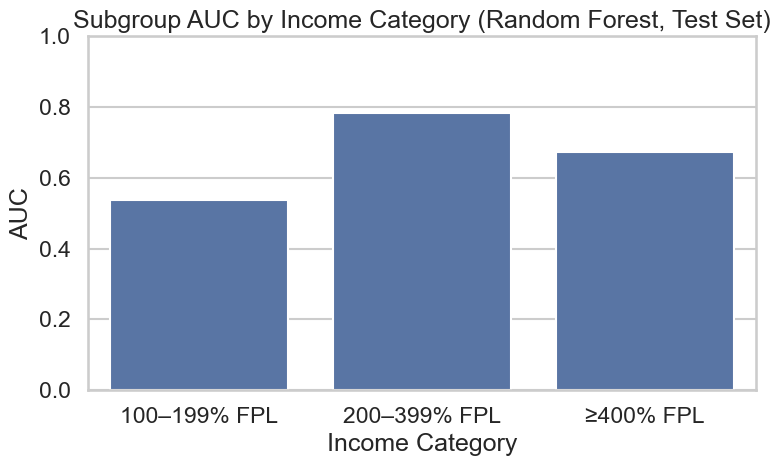

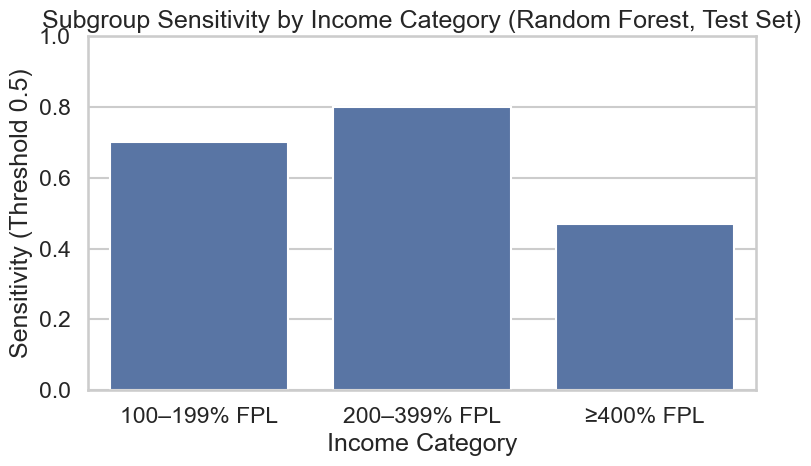

In [82]:
# Visualize subgroup AUC and sensitivity by income

if inc_perf_rf is not None and not inc_perf_rf.empty:
    # Nice printable table
    inc_perf_print = inc_perf_rf.copy()
    inc_perf_print["AUC"] = inc_perf_print["AUC"].round(3)
    inc_perf_print["Sensitivity"] = inc_perf_print["Sensitivity"].round(3)

    print("\nSubgroup performance by income category (Random Forest, test set):")
    print(inc_perf_print.to_string(index=False))

    # AUC plot
    order_inc = ["<100% FPL", "100–199% FPL", "200–399% FPL", "≥400% FPL"]
    order_inc = [c for c in order_inc if c in inc_perf_rf["income_cat"].values]

    plt.figure(figsize=(8, 5))
    sns.barplot(
        data=inc_perf_rf,
        x="income_cat",
        y="AUC",
        order=order_inc
    )
    plt.ylim(0, 1)
    plt.ylabel("AUC")
    plt.xlabel("Income Category")
    plt.title("Subgroup AUC by Income Category (Random Forest, Test Set)")
    plt.tight_layout()
    plt.show()

    # Sensitivity plot
    plt.figure(figsize=(8, 5))
    sns.barplot(
        data=inc_perf_rf,
        x="income_cat",
        y="Sensitivity",
        order=order_inc
    )
    plt.ylim(0, 1)
    plt.ylabel("Sensitivity (Threshold 0.5)")
    plt.xlabel("Income Category")
    plt.title("Subgroup Sensitivity by Income Category (Random Forest, Test Set)")
    plt.tight_layout()
    plt.show()

### <span style="color: blue;">Comment</span>

Subgroup performance by income varies across groups. AUC is modest for the 100-199% FPL group (AUC ≈ 0.54) and somewhat better AUC for 200–399% FPL (≈0.78) and ≥400% FPL (≈0.67). However, all of these are based on small test samples (N ≈ 20–40). 

Sensitivity at threshold 0.5 ranges from about 0.47 to 0.80, with the lowest sensitivity in the highest‑income group. These differences are likely not significant given the limited data and overall weak model performance.

**Interpretation:**

- **Race/ethnicity:**
The model performs at an AUC of about **0.74** for non‑Hispanic Black adults with sensitivity ≈ **0.67**, but only **0.26** AUC for non‑Hispanic White adults (N = 41) with sensitivity ≈ **0.77**. Thus, the model appears to predict risk of undiagnosis **better** for Black adults than for White adults. However, bootstrap CIs for these differences indicate that this difference is not significant because of small subgroup sizes, so we cannot draw conclusions about systematic performance gaps by race.

- **Income:**  
Subgroup performance is mixed by mixed. AUC is modest for **100–199% FPL** (AUC ≈ **0.54**, sensitivity ≈ **0.70**, N = 39), higher for **200–399% FPL** (AUC ≈ **0.78**, sensitivity ≈ **0.80**, N = 23), and intermediate for **≥400% FPL** (AUC ≈ **0.67**, sensitivity ≈ **0.47**, N = 23). These patterns are not monotonic with income and are based on small test samples, so caution should be taken when interpreting these as evidence of unfairness.

Overall, while subgroup AUC and sensitivity vary across race/ethnicity and income, the **small subgroup sizes** and **overall weak model performance** limit our ability to assess fairness rigorously. These results only partially speak to **H4**. This highlights the fact that fairness evaluation requires larger samples and stronger predictors, not just overall accuracy metrics.

## Ethics

**Ethics**

### A. Data Collection
- [X] **A.1 Informed consent**: If there are human subjects, have they given informed consent, where subjects affirmatively opt-in and have a clear understanding of the data uses to which they consent?

Participants give informed consent to be part of the original survey. Furthermore, the data of our project is public-use and de-identified. We will not collect new data from human subjects for this project.

- [X] **A.2 Collection bias**: Have we considered sources of bias that could be introduced during data collection and survey design and taken steps to mitigate those?

NHANES' mission statement is to be nationally representative. Nevertheless, it still excludes niche groups such as institutionalized people and the unhoused. When describing our results, we will take special care to emphasize that they apply only to the target population of NHANES and may miss some high-risk groups.

- [X] **A.3 Limit PII exposure**: Have we considered ways to minimize exposure of personally identifiable information (PII) for example through anonymization or not collecting information that isn't relevant for analysis?

The public-use NHANES files do not contain identifying information. Geographic information is present but limited. Though it is not possible to do any re-identification, our group will still adhere to the spirit of privacy and avoid any attempts to do so.

### B. Data Storage
- [X] **B.1 Data security**: Do we have a plan to protect and secure data (e.g., encryption at rest and in transit, access controls on internal users and third parties, access logs, and up-to-date software)?

Since the data is public-use and not sensitive, there is no need to take special care to secure data.

- [X] **B.2 Right to be forgotten**: Do we have a mechanism through which an individual can request their personal information be removed?

We have no way to remove individual participants because the data is deidentified. Requests for deidentification must be processed by the CDC.

- [X] **B.3 Data retention plan**: Is there a schedule or plan to delete the data after it is no longer needed?

Raw data files will only be stored as long as is needed to complete this course. Afterwards, data files will be deleted and only code and non-identifiable summary data will be kept.

### C. Analysis
- [X] **C.1 Missing perspectives**: Have we sought to address blindspots in the analysis through engagement with relevant stakeholders (e.g., checking assumptions and discussing implications with affected communities and subject matter experts)?

Our team does not have a qualified physician. Thus, we will make use of peer-reviewed studies in the field to interpret our findings, Additionally, we do not have an expert in public policy, and making suggestions about policy, even when our data seems to point in one direction, is very complex and disastrous if done wrongly. Thus, we will be careful to not over-state our results and avoid making direct suggestions on policy.

- [X] **C.2 Dataset bias**: Have we examined the data for possible sources of bias and taken steps to mitigate or address these biases (e.g., stereotype perpetuation, confirmation bias, imbalanced classes, or omitted confounding variables)?

One of our research questions is about equity. This involves explicitly characterizing the effect that dataset bias can have in model underperformance for disadvantaged groups. We acknowledge that there may still be some residual confounding in our predictive model that can bias estimates, but because this was not discovered during our extensive equity analysis, it is likely to not be possible to reduce with typical data science methods.

- [X] **C.3 Honest representation**: Are our visualizations, summary statistics, and reports designed to honestly represent the underlying data?

Our figures and tables will show confidence intervals and when survey weights are used clearly. This aligns with correct practices in using the data and will help us maintain the national representativeness of the data. We will also avoid cherry-picking results and common practices like data dredging.

- [X] **C.4 Privacy in analysis**: Have we ensured that data with PII are not used or displayed unless necessary for the analysis?

Given that the data is de-identified and diabetes is such a ubiquitous condition, we believe that re-identification is not a concern. This is in contrast to an analysis of, for example, a rare disease, where re-identification is a risk.

- [X] **C.5 Auditability**: Is the process of generating the analysis well documented and reproducible if we discover issues in the future?

All our analyses will take place in notebooks under Git version control. This ensures that our workflow is reproducible and verifiable.

### D. Modeling
- [X] **D.1 Proxy discrimination**: Have we ensured that the model does not rely on variables or proxies for variables that are unfairly discriminatory?

One of our research questions is about equity. This involves explicitly characterizing the effect that dataset bias can have in model underperformance for disadvantaged groups. Therefore, this concern is adequately addressed.

- [X] **D.2 Fairness across groups**: Have we tested model results for fairness with respect to different affected groups (e.g., tested for disparate error rates)?

Our project will explicitly measure model performance across race, ethnicity, income, and low healthcare access groups using AUC values. Possible causes for any disparities will be discussed.

- [X] **D.3 Metric selection**: Have we considered the effects of optimizing for our defined metrics and considered additional metrics?

We believe that for the purposes of our project, multiple metrics must be used in tandem, because each metric measures a slightly different facet of performance. These will be the standard metrics used to evaluate clinical model performance – AUC, sensitivity, specificity, PPV/NPV, and calibration. We will talk about the performance trade-offs that come with optimizing for any one of these metrics.

- [X] **D.4 Explainability**: Can we explain in understandable terms a decision the model made in cases where a justification is needed?

We will prioritize the development of interpretable models like logistic regression. We will also use carefully-chosen statistical measures like odds ratios and permutation importance, which will elucidate what our model is doing in human-understandable terms.

- [X] **D.5 Communicate limitations**: Have we communicated the shortcomings, limitations, and biases of the model to relevant stakeholders in ways that can be generally understood?

The conclusion of our project will clearly highlight the main limitations of our analysis. These are that our analysis does not establish causality and may affected by self-reporting bias, limited follow-up and measurement error. We will also emphasize that this model is only a proof-of-concept and not ready for cinical deployment.

### E. Deployment
- [X] **E.1 Monitoring and evaluation**: Do we have a clear plan to monitor the model and its impacts after it is deployed (e.g., performance monitoring, regular audit of sample predictions, human review of high-stakes decisions, reviewing downstream impacts of errors or low-confidence decisions, testing for concept drift)?

This model is a work-in-progress. It will not be implemented in a real-world setting without peer-review and further revisions based on that. However, we will discuss monitoring that must be undertaken were this model to be deployed, such as how to monitor model fairness.

- [X] **E.4 Unintended use**: Have we taken steps to identify and prevent unintended uses and abuse of the model and do we have a plan to monitor these once the model is deployed?

In our public Github repository, we will make it clear that this model is not ready-to-use, and it should not be incorporated into clinical wprkflows at its current state. This will prevent misunderstandings about the progress of the project.


## Discussion and Conclusion

### Summary of findings

In this project, we used NHANES 2017–2018 to study U.S. adults who met biomarker criteria for diabetes and asked who remained **undiagnosed** and why. We also testd whether non‑clinical variables can predict awareness of diabetes status and whether such models behave differently across subgroups (i.e. model fairness).

1. **Associations (RQ1):**
   - In survey‑weighted logistic regression, age, sex, race/ethnicity, education, income, insurance, smoking, and physical activity all showed statistically significant associations with being undiagnosed. Older age was associated with *lower* odds of underdiagnosis, while current smoking and some racial/ethnic minority groups (e.g., non‑Hispanic Black and non‑Hispanic Asian adults) had *higher* odds compared with reference groups.  
   - Patterns for socioeconomic status and insurance were **complex and counterintuitive** (e.g., non‑monotonic trends across income categories and higher odds of underdiagnosis among the insured subgroup). This is likely due primarily to small sample sizes of these subgroups. It is possible that there is some residual confounding as well, besides the mutual adjustment that logistic regression performs between variables.
   - The overall picture is broadly consistent with prior work: social and access‑related factors are linked to awareness, and some racial/ethnic minority groups remain more likely to be undiagnosed even after adjustment.

3. **Predictive performance (RQ2):**  
   - Predictive models using only non‑clinical features achieved **only modest discrimination** on held‑out data, with test AUCs in the range of roughly **0.45–0.56**, slightly better than chance. Logistic regression and a tuned random forest performed similarly, with higher AUC on the training set (≈0.7–0.75) than on the test set, indicating some overfitting and limited generalizability.  
   - Age, education, income, sex, smoking, and physical activity were the most important predictors across models, but their combined predictive signal was not strong enough to support accurate predictive performance for individuals.

4. **Fairness (RQ3):**  
   - We used random forest to perform analyses for each individual subgroup. We found some evidence for **heterogeneity in performance** across race/ethnicity and income categories. For example, test‑set AUC was higher for non‑Hispanic Black adults than for non‑Hispanic White adults, and AUC and sensitivity varied across income groups.  
   - However, subgroup sizes were small (often **N ≈ 20–40**), and bootstrap confidence intervals for differences between White and Black participants were not significant. As a result, we cannot make strong claims about systematic fairness gaps. Instead, these results might be viewed as **exploratory evidence** and that more data and stronger predictors are needed to assess equity rigorously.

### Reconciling tension between association and prediction results

One seemingly paradoxical finding of our project is that the survey‑weighted logistic regression produced many odds ratios with extremely small p‑values (i.e. highly significant), yet our predictive models showed only modest performance on held‑out data. 

This is not a contradiction, however. It reflects the difference between **detecting associations** and **making accurate individual‑level predictions**.

First, the logistic regression was fit on the full analytic sample using NHANES survey weights treated as frequency weights. This effectively inflates the sample size beyond what is contained in our analytic dataset. This makes p‑values extremely small so that even modest effect sizes appear “highly significant.” In contrast, our predictive models were evaluated on a separate test set and judged by how well they rank or classify individual cases, not by whether any coefficient is non‑zero. Predictive models, on the other hand, depend on strong effect sizes for their performance. This explains the gap we see.

In addition, amny other important factors such as provider behavior or individual beliefs are not included in our data but are highly relevant in whether a person receives diagnosis. This caps how well our model can perform on predictive tasks despite statistically significant associations being found.

### Connection to prior work

Our results align with previous NHANES‑based research showing that racial/ethnic minorities and individuals with lower socioeconomic status are more likely to have undiagnosed diabetes.[6–9] Our work built in this by the following:

- We focused on **biomarker‑positive** adults and explicitly modeled **awareness** (diagnosed vs. undiagnosed) rather than indidence of diabetes.
- We applied **survey‑weighted** regression to estimate associations while keeping our data nationally representative.
- We trained **predictive models** using only non‑clinical variables and explicitly assessing **fairness** via subgroup performance metrics.

Previous studies achieved very high AUC (e.g., ≈0.8–0.9) in their task of predicting incidence of diabetes with rich clinical features as variables. Our substantially lower AUC values reflect the fact that ours is a more challenging problem, and we attempted to solve it with a deliberately restricted predictor set. This indicates that there is still work to be done to make diabetes prediction models robust, fair and clinically applicable.

### Limitations

Our study has several limitations:

- **Cross‑sectional design:**  
  NHANES data is cross‑sectional, which means that we cannot make causal statements (e.g., “getting insurance will cause diagnosis”). This is because unmeasured confounders may influence both access to care and diagnosis.

- **Self‑reported variables:**  
  Diagnosis status, smoking, alcohol use, and some access variables are self‑reported. This makes them subject to recall bias and social desirability biases.

- **Complete‑case analysis:**  
  We performed a complete‑case analysis, wherein we dropped all individuals with missing values. Because smoking status and some socioeconomic variables were frequently missing, our modeling dataset shrank from 860 to 313 adults. If missingness is not random (e.g., more missing among the most disadvantaged), our analytic subset might not be nationally representative. This could bias estimates of associations and model performance.

- **Sample size in subgroups:**  
  Some race/ethnicity and income subgroups are relatively small, leading to wide confidence intervals and insignificant subgroup AUC estimates. This was seen in the fairness analysis and limits our ability to draw firm conclusions about performance gaps.

- **Approximate handling of survey design:**  
  We used NHANES survey weights in regression and evaluation, but we did not fully model the complex survey design (with strata and clusters, among other things). More advanced survey methods could refine our estimates to make them more nationally representative and potentially test whether some of the very small p‑values we observed reflect reality.


### What we have learned

Overall, this project reinforces that **access to care and social determinants** are central to diabetes awareness. Even among individuals whose lab values clearly indicate diabetes, whether they are actually diagnosed depends heavily on age, socioeconomic position, and access‑related factors linked to race/ethnicity and income.

At the same time, our predictive modeling results show that **non‑clinical variables alone are not sufficient** to accurately identify who is undiagnosed. Strong‑looking odds ratios in logistic regression do not automatically translate into a clinically useful risk score, which requires out‑of‑sample prediction and fairness across subgroups. The combination of small effect sizes and small subgroup sizes leads to only slightly better‑than‑chance prediction and less thorough fairness assessments.

### Future directions

We would love to continue this project beyond this class! Promising next steps might include:

- Incorporating richer **clinical data** to see if they improve prediction and by how much.
- Exploring **fairness‑aware training methods**, such as reweighting, adversarial debiasing, or group‑specific thresholds.
- Pooling multiple NHANES cycles (e.g., 1999–2018) to increase sample size and examine **trends across time** in underdiagnosis and model performance.
- Working with clinicians and community stakeholders to collaboratively design tools that combine predictive modeling with policy changes aimed at improving access and equity.

In summary, our project shows that non-clinical data might be able to help us characterize and partially predict who remains undiagnosed with diabetes in the U.S. It also illustrates the importance of distinguishing **association from prediction** and the movement of machine learning models to a more **equity-focused** approach, especially in healthcare.

Thank you for reaading!

In [83]:
print("\N{SMILING FACE WITH SUNGLASSES}")

😎
